# DQN AML Detection - SAML-D
**Kaan Gogcay | AML Research**

This notebook implements and evaluates a Deep Q-Network (DQN) for Anti-Money Laundering detection on the SAML-D dataset. The DQN architecture follows [Qayoom et al. (2024)](#references), the only pure Reinforcement Learning approach found in the literature for transaction monitoring on tabular data. The MDP framing follows [Vimal et al. (2021)](#references) and [Zhinin-Vera et al. (2020)](#references), and the reward function is grounded in the Imbalanced Classification Markov Decision Process established by [Lin et al. (2019)](#references). The DQN is benchmarked against the XGBoost baseline (Val AUPRC = 0.9136, Test AUPRC = 0.9275) established in `XGBoost_v9.0.ipynb`. Both models are evaluated on the same dataset under identical experimental conditions to ensure a fair comparison.


<h2>Contents</h2>

- [0. Imports](#0-imports)
- [1. Data Preparation](#1-data-preparation)
    - [1.1 Load Splits](#11-load-splits)
    - [1.2 Preprocessing](#12-preprocessing)
- [2. DQN Architecture](#2-dqn-architecture)
    - [2.1 Environment](#21-environment)
    - [2.2 Neural Network](#22-neural-network)
    - [2.3 Agent](#23-agent)
- [3. Iteration 1: Lin et al. (2019)](#3-iteration-1-lin-et-al-2019)
    - [3.1 Training Configuration](#31-training-configuration)
    - [3.2 Training Loop](#32-training-loop)
    - [3.3 Training Curves](#33-training-curves)
    - [3.4 Evaluation](#34-evaluation)
- [4. Iteration 2: Zhinin-Vera et al. (2020)](#4-iteration-2-zhinin-vera-et-al-2020)
    - [4.1 Training Configuration](#41-training-configuration)
    - [4.2 Training Loop](#42-training-loop)
    - [4.3 Training Curves](#43-training-curves)
    - [4.4 Evaluation](#44-evaluation)
- [5. Iteration 3: Zhinin-Vera et al. (2020) — Adjusted Epsilon Decay](#5-iteration-3-zhinin-vera-et-al-2020--adjusted-epsilon-decay)
    - [5.1 Training Configuration](#51-training-configuration)
    - [5.2 Training Loop](#52-training-loop)
    - [5.3 Training Curves](#53-training-curves)
    - [5.4 Evaluation](#54-evaluation)
- [6. Iteration 4: Zhinin-Vera et al. (2020) — Dropout Regularisation](#6-iteration-4-zhinin-vera-et-al-2020--dropout-regularisation)
    - [6.1 Training Configuration](#61-training-configuration)
    - [6.2 Q-Network with Dropout](#62-q-network-with-dropout)
    - [6.3 Training Loop](#63-training-loop)
    - [6.4 Training Curves](#64-training-curves)
    - [6.5 Evaluation](#65-evaluation)
- [7. Iteration 5: Zhinin-Vera et al. (2020) — Reduced Dropout Rate](#7-iteration-5-zhinin-vera-et-al-2020--reduced-dropout-rate)
    - [7.1 Training Configuration](#71-training-configuration)
    - [7.2 Training Loop](#72-training-loop)
    - [7.3 Training Curves](#73-training-curves)
    - [7.4 Evaluation](#74-evaluation)
- [9. Comparison](#9-comparison)
    - [9.1 Best Models](#91-best-models)
- [11. Summary](#11-summary)
- [12. References](#12-references)

---

# 0. Imports
Package imports and versioning

In [1]:
import torch, xgboost, sklearn, pandas, numpy, shap, matplotlib, sys
print('torch      :', torch.__version__, '| CUDA:', torch.cuda.is_available())
print('xgboost    :', xgboost.__version__)
print('sklearn    :', sklearn.__version__)
print('pandas     :', pandas.__version__)
print('numpy      :', numpy.__version__)
print('shap       :', shap.__version__)
print('matplotlib :', matplotlib.__version__)
print('Python     :', sys.version[:8])

torch      : 2.6.0+cu124 | CUDA: True
xgboost    : 2.1.1
sklearn    : 1.5.2
pandas     : 2.2.2
numpy      : 1.26.4
shap       : 0.46.0
matplotlib : 3.9.2
Python     : 3.10.15 


# 1. Data Preperation

All data exploration and preperation is documented in `Data_Exploration_and_Preperation_v1.7.ipynb`. 

## 1.1 Load Splits

In [2]:
# [1.1a] Load Splits
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import shap
import matplotlib.pyplot as plt
import random
import collections
import time
from sklearn.metrics import average_precision_score, precision_recall_curve, classification_report
from sklearn.preprocessing import StandardScaler

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Load pre-processed splits — produced by eda
train_df = pd.read_csv('../dataset_FE_2/train.csv')
val_df   = pd.read_csv('../dataset_FE_2/val.csv')
test_df  = pd.read_csv('../dataset_FE_2/test.csv')

print(f'Split sizes — Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    rate = split['Is_laundering'].mean() * 100
    print(f'  {name} laundering rate: {rate:.4f}%')

Device: cuda
Split sizes — Train: 6,653,396 | Val: 1,425,728 | Test: 1,425,728
  Train laundering rate: 0.1017%
  Val laundering rate: 0.0990%
  Test laundering rate: 0.1190%


## 1.2 Preprocessing

Unlike XGBoost, which handles categorical features natively, neural networks require numeric inputs. The five categorical columns (payment currency, received currency, sender bank location, receiver bank location, payment type) are therefore one-hot encoded, expanding the original 27 features to 91.

One-hot encoding alone does not address the large differences in feature scale across the dataset. For example, `Amount` ranges from `3.73 to 12,618,498.40`, while `pair_tx_count` ranges from `1` to `62`, and all one-hot encoded features are bounded between `0` and `1`. Feeding these raw values into a neural network is problematic because features with larger magnitudes dominate the gradient updates, as neural network training relies on gradient descent which is sensitive to the relative scale of inputs. There are two ways to address this problem: normalisation and standardisation.

### Normalisation
Normalisation (min-max scaling) rescales each feature to a fixed range, typically [0, 1] or [-1, 1], by subtracting the minimum and dividing by the range. It preserves the relative distances between values but is sensitive to outliers. A single extreme value compresses all other values into a narrow range near zero.

### Standardisation
Standardisation (z-score scaling) transforms each feature to have a mean of 0 and a standard deviation of 1. A value is transformed by subtracting the feature mean and dividing by its standard deviation. Unlike normalisation, it does not depend on the minimum or maximum values, making it more robust to outliers [(Han et al., 2011)](#8-references).

### My choice and why
Standardisation was chosen over normalisation due to the heavy-tailed distributions present in the dataset. For example, Amount has a mean of 8,799 but a maximum of 12,618,498, with a standard deviation exceeding three times the mean. Under min-max normalisation, such extreme values would compress the majority of transactions into a narrow range near zero, effectively discarding useful variation. Standardisation handles this more robustly. The scaler was fitted exclusively on the training set and applied to the validation and test sets, preventing data leakage.

### Example
The following example illustrates how a single transaction is transformed through each stage of the preprocessing pipeline.

| Feature | Raw | Encoded | Standarised |
|---|---|---|---|
| Amount | 1459.15 | 1459.15 | -0.284 |
| sender_tx_count | 9 | 9 | -1.288 |
| sender_amount_mean | 1943.77 | 1943.77 | -0.980 |
| sender_amount_std | 1825.81 | 1825.81 | -0.602 |
| sender_amount_min | 335.67 | 335.67 | -0.419 |
| sender_amount_max | 4879.60 | 4879.60 | -0.724 |
| sender_unique_receivers | 1 | 1 | -1.294 |
| fan_out_ratio | 0.111 | 0.111 | -0.002 |
| is_cross_border | 0 | 0 | -0.330 |
| Payment_type | Cash Deposit | - | - |
| Payment_type_ACH | - | 0 | -0.518 |
| Payment_type_Cash Deposit | - | 1 | 6.411 |
| Payment_type_Cash Withdrawal | - | 0 | -0.181 |
| Payment_currency | UK pounds | - | - |
| Payment_currency_UK pounds | - | 1 | 0.210 |
| Payment_currency_US dollar | - | 0 | -0.052 |
| Sender_bank_location | UK | - | - |
| Sender_bank_location_UK | - | 1 | 0.186 |
| Sender_bank_location_USA | - | 0 | -0.044 |
| Receiver_bank_location | UK | - | - |
| Receiver_bank_location_UK | - | 1 | 0.269 |
| Receiver_bank_location_USA | - | 0 | -0.063 |
| ... | ... | ... | ... |

All 91 values are now on a comparable scale. The agent receives this as a 91-element float array and outputs a Q-value for each of the two actions.

In [3]:
# [1.2a] describe
train_df.describe()

,Sender_account,Receiver_account,Amount,Is_laundering,sender_tx_count,sender_amount_mean,sender_amount_std,sender_amount_min,sender_amount_max,sender_unique_receivers,...,receiver_amount_mean,receiver_amount_std,receiver_unique_senders,receiver_unique_currencies,receiver_unique_locations,pair_tx_count,fan_out_ratio,fan_in_ratio,is_cross_currency,is_cross_border
count,6.653396e+06,6.653396e+06,6.653396e+06,6.653396e+06,6.653396e+06,6.653396e+06,6.653396e+06,6.653396e+06,6.653396e+06,6.653396e+06,...,6.653396e+06,6.653396e+06,6.653396e+06,6.653396e+06,6.653396e+06,6.653396e+06,6.653396e+06,6.653396e+06,6.653396e+06,6.653396e+06
mean,5.007006e+09,5.010917e+09,8.799571e+03,1.016624e-03,2.193995e+02,8.799571e+03,1.434461e+04,2.969730e+03,1.940510e+05,2.345626e+01,...,8.799571e+03,2.709986e+03,5.542960e+00,1.545669e+00,1.229212e+00,1.288283e+01,1.112642e-01,1.112642e-01,1.141383e-01,9.821811e-02
std,2.883028e+09,2.885528e+09,2.581833e+04,3.186833e-02,1.633217e+02,6.993450e+03,2.079723e+04,6.289339e+03,2.613383e+05,1.735697e+01,...,2.244249e+04,1.296514e+04,7.689930e+00,1.058404e+00,5.972570e-01,8.759181e+00,7.083426e-02,1.145968e-01,3.179791e-01,2.976094e-01
min,2.851100e+04,1.326600e+04,3.730000e+00,0.000000e+00,1.000000e+00,5.814000e+01,0.000000e+00,3.730000e+00,5.814000e+01,1.000000e+00,...,8.464545e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.612903e-02,1.694915e-02,0.000000e+00,0.000000e+00
25%,2.520472e+09,2.522946e+09,2.141180e+03,0.000000e+00,1.200000e+01,6.187185e+03,8.254603e+02,3.316000e+01,1.496597e+04,1.000000e+00,...,2.649924e+03,7.758523e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+01,8.333333e-02,7.692308e-02,0.000000e+00,0.000000e+00
50%,5.000603e+09,5.008076e+09,6.115650e+03,0.000000e+00,2.330000e+02,8.055316e+03,8.934205e+03,6.627000e+01,8.191195e+04,2.700000e+01,...,7.384770e+03,5.463724e+02,1.000000e+00,1.000000e+00,1.000000e+00,1.200000e+01,1.048387e-01,8.745247e-02,0.000000e+00,0.000000e+00
75%,7.497167e+09,7.505262e+09,1.043313e+04,0.000000e+00,3.590000e+02,1.000042e+04,2.071692e+04,4.479750e+03,3.010896e+05,3.700000e+01,...,1.089465e+04,4.604607e+03,1.100000e+01,2.000000e+00,1.000000e+00,1.300000e+01,1.204819e-01,1.013216e-01,0.000000e+00,0.000000e+00
max,9.999913e+09,9.999971e+09,1.261850e+07,1.000000e+00,5.940000e+02,3.146963e+06,3.994030e+06,7.613573e+05,1.261850e+07,5.800000e+01,...,6.475297e+06,3.309655e+06,4.100000e+01,9.000000e+00,1.000000e+01,6.200000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [4]:
# [1.2b] Encoding and Scaling
# Drop label columns — Laundering_type is label leakage
DROP_COLS = ['Is_laundering', 'Laundering_type']

def prepare(split_df):
    X = split_df.drop(columns=DROP_COLS)
    y = split_df['Is_laundering'].values
    return X, y

X_train_raw, y_train = prepare(train_df)
X_val_raw,   y_val   = prepare(val_df)
X_test_raw,  y_test  = prepare(test_df)

# One-hot encode categorical features
CAT_COLS = ['Payment_currency', 'Received_currency',
            'Sender_bank_location', 'Receiver_bank_location', 'Payment_type']

# Fit encoder on training set only — apply to all sets
X_train_enc = pd.get_dummies(X_train_raw, columns=CAT_COLS)
X_val_enc   = pd.get_dummies(X_val_raw,   columns=CAT_COLS)
X_test_enc  = pd.get_dummies(X_test_raw,  columns=CAT_COLS)

# Align columns — val/test may have unseen categories; fill missing with 0
X_val_enc  = X_val_enc.reindex(columns=X_train_enc.columns, fill_value=0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

FEATURE_NAMES = X_train_enc.columns.tolist()
N_FEATURES    = len(FEATURE_NAMES)
print(f'Features after encoding: {N_FEATURES}')

# Standardise — fit on training set only
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_enc).astype(np.float32)
X_val_sc   = scaler.transform(X_val_enc).astype(np.float32)
X_test_sc  = scaler.transform(X_test_enc).astype(np.float32)

print(f'Training matrix shape   : {X_train_sc.shape}')
print(f'Validation matrix shape : {X_val_sc.shape}')
print(f'Test matrix shape       : {X_test_sc.shape}')

Features after encoding: 91
Training matrix shape   : (6653396, 91)
Validation matrix shape : (1425728, 91)
Test matrix shape       : (1425728, 91)


In [5]:
# [1.2c] Sample for Example
# Get the same row from the raw (pre-encoded) dataframe
print(train_df.iloc[0])

Sender_account                          8724731955
Receiver_account                        2769355426
Amount                                     1459.15
Payment_currency                         UK pounds
Received_currency                        UK pounds
Sender_bank_location                            UK
Receiver_bank_location                          UK
Payment_type                          Cash Deposit
Is_laundering                                    0
Laundering_type               Normal_Cash_Deposits
sender_tx_count                                  9
sender_amount_mean                     1943.768889
sender_amount_std                      1825.809046
sender_amount_min                           335.67
sender_amount_max                           4879.6
sender_unique_receivers                          1
sender_unique_currencies                         1
sender_unique_locations                          1
receiver_tx_count                               17
receiver_amount_mean           

In [6]:
# [1.2d] Sample for Example 2
sample_before = X_train_enc.iloc[0]
sample_scaled = scaler.transform(sample_before.values.reshape(1, -1))

comparison = pd.DataFrame({
    'Feature': X_train_enc.columns,
    'Encoded': sample_before.values,
    'Scaled': sample_scaled[0]
})

print(comparison.to_markdown(index=False))

| Feature                            |        Encoded |      Scaled |
|:-----------------------------------|---------------:|------------:|
| Sender_account                     |    8.72473e+09 |  1.28952    |
| Receiver_account                   |    2.76936e+09 | -0.776829   |
| Amount                             | 1459.15        | -0.284311   |
| sender_tx_count                    |    9           | -1.28825    |
| sender_amount_mean                 | 1943.77        | -0.980318   |
| sender_amount_std                  | 1825.81        | -0.601945   |
| sender_amount_min                  |  335.67        | -0.418813   |
| sender_amount_max                  | 4879.6         | -0.723856   |
| sender_unique_receivers            |    1           | -1.29379    |
| sender_unique_currencies           |    1           | -1.01241    |
| sender_unique_locations            |    1           | -0.913938   |
| receiver_tx_count                  |   17           | -0.507457   |
| receiver_amount_me

c:\Users\thezo\anaconda3\envs\aml_dqn\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


---

# 2. DQN Architecture

This section defines the three components of the DQN system: the environment, the neural network that approximates the Q-value function, and the agent that controls training. The architecture is shared across both iterations, only the hyperparameters differ.

## 2.1 Environment
Reinforcement Learning requires framing the problem as a Markov Decision Process (MDP) with states, actions, and rewards, following the formulation of [Lin et al. (2019)](#references), [Vimal et al. (2021)](#references) and [Zhinin-Vera et al. (2020)](#references) who all apply this framework to transaction fraud detection. For AML transaction monitoring on static tabular data, this framing is adapted as follows.

**State:** Each transaction is a state. The state vector is the full set of engineered features (91) for that transaction.

**Action space:** The agent chooses between two discrete actions at each step: action 0 (predict normal) and action 1 (predict suspicious). The Q-network outputs a Q-value for each action, and the agent selects the action with the highest Q-value.

**Reward function:** There are 2 papers on this specific topic:

- [Lin et al. (2019)](#references), who define a reward structure for imbalanced classification using reinforcement learning in which the minority class receives reward ±1 and the majority class receives ±λ, with the smaller magnitude for the majority class justified by the greater impact of correctly classifying the minority class. After experimenting they reported that the best results are achieved when λ is equal to the imbalance ratio. 

- [Zhinin-Vera et al. (2020)](#references), who uses Lin et al. mostly as a guideline throughout their research show that results are best when λ is equal to 0.1, however this does not equal their imbalance rate, as their imbalance rate it 0.001728.

Since both experiments claim to find good performing values for λ, both will be tested in separate iterations. The model achieving the best results will be further optimized.

Iteration 1 (following [Lin et al. (2019)](#references))
| Prediction | Ground truth | Reward | Rationale |
|---|---|---|---|
| Suspicious (1) | Laundering (1) | +1.0 | True positive: correct minority class detection |
| Normal (0) | Laundering (1) | -1.0 | False negative: incorrect minority class, highest penalty |
| Suspicious (1) | Normal (0) | -0.001039 | False positive: incorrect majority class |
| Normal (0) | Normal (0) | +0.001039 | True negative: correct majority class |

Iteration 2 (following [Zhinin-Vera et al. (2020)](#references))
| Prediction | Ground truth | Reward | Rationale |
|---|---|---|---|
| Suspicious (1) | Laundering (1) | +1.0 | True positive: correct minority class detection |
| Normal (0) | Laundering (1) | -1.0 | False negative: incorrect minority class, highest penalty |
| Suspicious (1) | Normal (0) | -0.1 | False positive: incorrect majority class |
| Normal (0) | Normal (0) | +0.1 | True negative: correct majority class |

**Episode structure:** Each transaction is treated as an independent single-step episode, following the ICMDP framework of [Lin et al. (2019)](#references) and [Zhinin-Vera et al. (2020)](#references), who both process one sample per episode. To stay consistent with the respective source of each iteration, Iteration 1 uses γ = 0.1 following [Lin et al. (2019)](#references) and Iteration 2 uses γ = 0.9 following [Zhinin-Vera et al. (2020)](#references).

In [7]:
class AMLEnvironment:
    """
    AML transaction monitoring environment for a DQN agent.
    Reward values are set per iteration via the REWARD dict,
    which is initialised in each iteration's configuration cell.

    Actions
    -------
    0 : predict normal
    1 : predict suspicious
    """

    N_ACTIONS = 2

    def __init__(self, X: np.ndarray, y: np.ndarray, reward_dict: dict):
        self.X      = X
        self.y      = y
        self.n      = len(X)
        self.idx    = 0
        self.REWARD = reward_dict

    def reset(self):
        perm     = np.random.permutation(self.n)
        self.X   = self.X[perm]
        self.y   = self.y[perm]
        self.idx = 0
        return self.X[0]

    def step(self, action: int):
        label      = int(self.y[self.idx])
        reward     = self.REWARD[action][label]
        self.idx  += 1
        done       = self.idx >= self.n
        next_state = None if done else self.X[self.idx]
        return next_state, reward, done

## 2.2 Neural Network

The Q-network approximates the Q-value function Q(s, a), mapping a transaction's feature vector to a Q-value for each of the two actions. The architecture follows [Qayoom et al. (2024)](#references), whose network is specifically designed for static tabular transaction data with a raw feature vector as input, making it the most directly applicable architecture in the literature for this problem.

| Layer | Neurons | Activation |
|---|---|---|
| Input | `N_FEATURES` | - |
| Hidden 1 | 124 | ReLU |
| Hidden 2 | 62 | ReLU |
| Hidden 3 | 31 | Tanh |
| Hidden 4 | 15 | Linear |
| Output | 2 | Linear |

[Qayoom et al. (2024)](#references) use a sigmoid output because their network outputs a single fraud probability. Here the output layer has two neurons (one Q-value per action), with no activation so that Q-values can be positive or negative.

In [8]:
class QNetwork(nn.Module):
    """
    Deep Q-Network following Qayoom et al. (2024).

    Architecture: Input -> 124 (ReLU) -> 62 (ReLU) -> 31 (Tanh) -> 15 (Linear) -> 2 (output)
    Output: raw Q-values for each action (no activation on final layer).
    """

    def __init__(self, n_features: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 124), nn.ReLU(),
            nn.Linear(124, 62),         nn.ReLU(),
            nn.Linear(62,  31),         nn.Tanh(),
            nn.Linear(31,  15),
            nn.Linear(15,   2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

# Verify architecture
dummy_net = QNetwork(N_FEATURES)
dummy_in  = torch.zeros(1, N_FEATURES)
dummy_out = dummy_net(dummy_in)
print(dummy_net)
print(f'Input size  : {N_FEATURES}')
print(f'Output shape: {dummy_out.shape}  (Q-value per action)')

QNetwork(
  (net): Sequential(
    (0): Linear(in_features=91, out_features=124, bias=True)
    (1): ReLU()
    (2): Linear(in_features=124, out_features=62, bias=True)
    (3): ReLU()
    (4): Linear(in_features=62, out_features=31, bias=True)
    (5): Tanh()
    (6): Linear(in_features=31, out_features=15, bias=True)
    (7): Linear(in_features=15, out_features=2, bias=True)
  )
)
Input size  : 91
Output shape: torch.Size([1, 2])  (Q-value per action)


## 2.3 Agent

The DQN agent implements:

**Epsilon-greedy exploration:** The agent selects a random action with probability epsilon and the greedy action (highest Q-value) otherwise. Epsilon starts at 1.0 (fully random), decays each step, and floors at 0.01, following [Lin et al. (2019)](#references). This ensures the agent explores early in training and increasingly exploits learned knowledge as it converges.

**Experience replay:** Transitions (state, action, reward, next_state, done) are stored in a fixed-size replay buffer, from which random mini-batches are sampled for training. This breaks the correlation between consecutive transitions and stabilises gradient updates, a core DQN technique introduced by [Mnih et al. (2015)](#references) and adopted by all three source papers. Across these papers, the buffer is consistently large enough to store the entire training dataset: [Lin et al. (2019)](#references) use a buffer of 50,000 which fits all their training sets (largest is Mnist at ~54,000 samples total, of which ~90% is used for training per their Table I); [Zhinin-Vera et al. (2020)](#references) use 200,000 on a dataset of 284,807 transactions, assuming a standard 70/30 train/test split gives ~199,365 training samples, which the buffer fits entirely; and [Qayoom et al. (2024)](#references) use 250 on a training set of 248 samples. None of the papers explicitly justify their buffer size choice, and the split ratio for Zhinin-Vera et al. is not stated and is assumed here. Nonetheless, the consistent pattern across all three suggests the intent is to retain the full diversity of training experiences in the buffer at all times. Applying this principle to SAML-D's 6,653,396 training transactions, a buffer of equivalent size is used. Given the 32GB RAM available, storing the full training set in the replay buffer is considered feasible and is therefore implemented accordingly.

**Target network:** A separate target network Q* is maintained as a periodically updated copy of the online Q-network, following [Qayoom et al. (2024)](#references) and [Mnih et al. (2015)](#references) who introduced it as a core DQN stabilisation technique. While [Lin et al. (2019)](#references) and [Zhinin-Vera et al. (2020)](#references) do not use a target network, it is retained here.

**Loss:** Mean squared error between the predicted Q-values and the Bellman target, optimised with Adam. [Lin et al. (2019)](#references) use a learning rate of 0.00025 and [Qayoom et al. (2024)](#references) use 0.0001. Since Lin et al. operate on a dataset scale more comparable to SAML-D than Qayoom et al., a learning rate of 0.00025 is adopted following [Lin et al. (2019)](#references).

In [9]:
class ReplayBuffer:
    """
    Pre-allocated numpy replay buffer.
    Uses fixed arrays instead of a deque to keep memory usage close to
    the theoretical minimum — essential for the full-training-set buffer
    of 6.6 million entries (~4.92 GB).
    """

    def __init__(self, capacity: int, n_features: int):
        self.capacity  = capacity
        self.n_features = n_features
        self.ptr       = 0
        self.size      = 0

        self.states      = np.zeros((capacity, n_features), dtype=np.float32)
        self.next_states = np.zeros((capacity, n_features), dtype=np.float32)
        self.actions     = np.zeros(capacity, dtype=np.int64)
        self.rewards     = np.zeros(capacity, dtype=np.float32)
        self.dones       = np.zeros(capacity, dtype=np.float32)

    def push(self, state, action, reward, next_state, done):
        self.states[self.ptr]      = state
        self.next_states[self.ptr] = next_state
        self.actions[self.ptr]     = action
        self.rewards[self.ptr]     = reward
        self.dones[self.ptr]       = float(done)
        self.ptr  = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size: int):
        idx = np.random.randint(0, self.size, size=batch_size)
        return (
            self.states[idx],
            self.actions[idx],
            self.rewards[idx],
            self.next_states[idx],
            self.dones[idx],
        )

    def __len__(self):
        return self.size


class DQNAgent:
    """
    DQN agent.

    Architecture follows Qayoom et al. (2024).
    Epsilon-greedy and learning rate follow Lin et al. (2019).
    Experience replay buffer sized to full training set.
    Target network follows Mnih et al. (2015) and Qayoom et al. (2024).
    """

    def __init__(
        self,
        n_features         : int,
        memory_size        : int   = 6653396,
        batch_size         : int   = 256,
        gamma              : float = 0.1,
        epsilon            : float = 1.0,
        epsilon_decay      : float = 0.00001,
        epsilon_min        : float = 0.01,
        lr                 : float = 0.00025,
        train_freq         : int   = 10,
        target_update_freq : int   = 20,
    ):
        self.n_features         = n_features
        self.batch_size         = batch_size
        self.gamma              = gamma
        self.epsilon            = epsilon
        self.epsilon_decay      = epsilon_decay
        self.epsilon_min        = epsilon_min
        self.train_freq         = train_freq
        self.target_update_freq = target_update_freq

        self.q_network      = QNetwork(n_features).to(DEVICE)
        self.target_network = QNetwork(n_features).to(DEVICE)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

        self.optimiser = optim.Adam(self.q_network.parameters(), lr=lr)
        self.loss_fn   = nn.MSELoss()
        self.memory    = ReplayBuffer(memory_size, n_features)

    def select_action(self, state: np.ndarray) -> int:
        if random.random() < self.epsilon:
            return random.randint(0, 1)
        state_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            q_vals = self.q_network(state_t)
        return int(q_vals.argmax().item())

    def store(self, state, action, reward, next_state, done):
        ns = next_state if next_state is not None else np.zeros(self.n_features, dtype=np.float32)
        self.memory.push(state, action, reward, ns, done)

    def train_step(self) -> float | None:
        if len(self.memory) < self.batch_size:
            return None
        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        states_t      = torch.FloatTensor(states).to(DEVICE)
        actions_t     = torch.LongTensor(actions).to(DEVICE)
        rewards_t     = torch.FloatTensor(rewards).to(DEVICE)
        next_states_t = torch.FloatTensor(next_states).to(DEVICE)
        dones_t       = torch.FloatTensor(dones).to(DEVICE)
        q_values      = self.q_network(states_t).gather(1, actions_t.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            max_next_q = self.target_network(next_states_t).max(1)[0]
            targets    = rewards_t + self.gamma * max_next_q * (1 - dones_t)
        loss = self.loss_fn(q_values, targets)
        self.optimiser.zero_grad()
        loss.backward()
        self.optimiser.step()
        return loss.item()

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon - self.epsilon_decay)

    def update_target(self):
        self.target_network.load_state_dict(self.q_network.state_dict())

    def get_scores(self, X: np.ndarray) -> np.ndarray:
        """
        Compute suspiciousness score for each transaction.
        Score is the softmax probability of action 1 (suspicious),
        producing a calibrated value in [0, 1] suitable for AUPRC.
        """
        self.q_network.eval()
        scores = []
        batch  = 4096
        with torch.no_grad():
            for i in range(0, len(X), batch):
                x_t   = torch.FloatTensor(X[i:i+batch]).to(DEVICE)
                q     = self.q_network(x_t)
                probs = torch.softmax(q, dim=1)[:, 1]
                scores.append(probs.cpu().numpy())
        self.q_network.train()
        return np.concatenate(scores)


print('ReplayBuffer (numpy) and DQNAgent defined.')

ReplayBuffer (numpy) and DQNAgent defined.


---

# 3. Iteration 1: Lin et al. (2019)

Iteration 1 implements the reward function of [Lin et al. (2019)](#references), who establish that the optimal λ equals the class imbalance ratio ρ. For SAML-D, ρ = 0.001039, giving λ = 0.001039. The discount factor is set to γ = 0.1 following [Lin et al. (2019)](#references).

## 3.1 Training Configuration

Hyperparameters follow [Qayoom et al. (2024)](#references) as the architectural baseline, scaled for SAML-D's dataset size. The reward-specific parameters λ and γ follow [Lin et al. (2019)](#references).

In [10]:
# Iteration 1 — Lin et al. (2019): λ = ρ = 0.001039, γ = 0.1
N_EPOCHS           = 100      # early stopping will terminate before this if converged
MEMORY_SIZE        = 6653396  # full training set buffer — Lin et al. principle
BATCH_SIZE         = 256      # scaled for SAML-D
GAMMA              = 0.1      # Lin et al. (2019)
LAMBDA             = 0.001039 # Lin et al. (2019): λ = ρ = |DP|/|DN|
EPSILON_START      = 1.0      # Lin et al. (2019)
EPSILON_DECAY      = 0.00001  # scaled down after testing higher numbers
EPSILON_MIN        = 0.01     # Lin et al. (2019)
LR                 = 0.00025  # Lin et al. (2019)
TRAIN_FREQ         = 10       # Qayoom et al. (2024)
TARGET_UPDATE_FREQ = 20       # Qayoom et al. (2024)

EARLY_STOPPING_PATIENCE  = 10
EARLY_STOPPING_MIN_DELTA = 0.001

print('Iteration 1 — Lin et al. (2019):')
print(f'  Lambda (λ)          : {LAMBDA}')
print(f'  Gamma (γ)           : {GAMMA}')
print(f'  Epochs (max)        : {N_EPOCHS}')
print(f'  Memory size         : {MEMORY_SIZE:,}')
print(f'  Batch size          : {BATCH_SIZE}')
print(f'  Epsilon start/decay/min: {EPSILON_START} / {EPSILON_DECAY} / {EPSILON_MIN}')
print(f'  Learning rate       : {LR}')
print(f'  Train freq          : {TRAIN_FREQ}')
print(f'  Target update freq  : {TARGET_UPDATE_FREQ}')
print(f'  Device              : {DEVICE}')

Iteration 1 — Lin et al. (2019):
  Lambda (λ)          : 0.001039
  Gamma (γ)           : 0.1
  Epochs (max)        : 100
  Memory size         : 6,653,396
  Batch size          : 256
  Epsilon start/decay/min: 1.0 / 1e-05 / 0.01
  Learning rate       : 0.00025
  Train freq          : 10
  Target update freq  : 20
  Device              : cuda


## 3.2 Training Loop

In [11]:
# # Initialise agent and environment — Iteration 1
# agent_v1 = DQNAgent(
#     n_features         = N_FEATURES,
#     memory_size        = MEMORY_SIZE,
#     batch_size         = BATCH_SIZE,
#     gamma              = GAMMA,
#     epsilon            = EPSILON_START,
#     epsilon_decay      = EPSILON_DECAY,
#     epsilon_min        = EPSILON_MIN,
#     lr                 = LR,
#     train_freq         = TRAIN_FREQ,
#     target_update_freq = TARGET_UPDATE_FREQ,
# )

# history_v1 = {
#     'epoch'       : [],
#     'reward'      : [],
#     'loss'        : [],
#     'epsilon'     : [],
#     'train_auprc' : [],
#     'val_auprc'   : [],
#     'elapsed'     : [],
# }

# best_val_auprc_v1 = 0.0
# no_improve_count  = 0
# total_start       = time.time()

# for epoch in range(1, N_EPOCHS + 1):
#     epoch_start = time.time()

#     perm       = np.random.permutation(len(X_train_sc))
#     X_shuffled = X_train_sc[perm]
#     y_shuffled = y_train[perm]

#     total_reward = 0.0
#     losses       = []
#     step_count   = 0
#     CHUNK        = 512
#     n_chunks     = (len(X_shuffled) + CHUNK - 1) // CHUNK

#     for ci, i in enumerate(range(0, len(X_shuffled), CHUNK)):
#         states = X_shuffled[i:i+CHUNK]
#         labels = y_shuffled[i:i+CHUNK]

#         if random.random() < agent_v1.epsilon:
#             actions = np.random.randint(0, 2, size=len(states))
#         else:
#             with torch.no_grad():
#                 q = agent_v1.q_network(torch.FloatTensor(states).to(DEVICE))
#             actions = q.argmax(dim=1).cpu().numpy()

#         rewards = np.where(
#             actions == 1,
#             np.where(labels == 1, +1.0,    -LAMBDA),
#             np.where(labels == 1, -1.0,    +LAMBDA),
#         ).astype(np.float32)

#         total_reward += rewards.sum()

#         for j in range(len(states)):
#             done_flag  = (i + j + 1) >= len(X_shuffled)
#             next_state = X_shuffled[i+j+1] if not done_flag else np.zeros(N_FEATURES, dtype=np.float32)
#             agent_v1.memory.push(states[j], int(actions[j]), float(rewards[j]), next_state, done_flag)

#         agent_v1.decay_epsilon()
#         step_count += len(states)

#         if step_count % TRAIN_FREQ == 0:
#             loss = agent_v1.train_step()
#             if loss is not None:
#                 losses.append(loss)

#         if step_count % TARGET_UPDATE_FREQ == 0:
#             agent_v1.update_target()

#         if (ci + 1) % 1000 == 0:
#             elapsed = time.time() - epoch_start
#             pct     = (ci + 1) / n_chunks * 100
#             print(f'  Epoch {epoch} | {pct:.1f}% | {elapsed:.0f}s elapsed', end='\r')

#     # Evaluate train (fixed 50k sample) and validation
#     train_sample_idx = np.random.choice(len(X_train_sc), size=50000, replace=False)
#     train_scores     = agent_v1.get_scores(X_train_sc[train_sample_idx])
#     train_auprc      = average_precision_score(y_train[train_sample_idx], train_scores)

#     val_scores = agent_v1.get_scores(X_val_sc)
#     val_auprc  = average_precision_score(y_val, val_scores)

#     epoch_loss    = np.mean(losses) if losses else float('nan')
#     epoch_elapsed = time.time() - epoch_start

#     history_v1['epoch'].append(epoch)
#     history_v1['reward'].append(total_reward)
#     history_v1['loss'].append(epoch_loss)
#     history_v1['epsilon'].append(agent_v1.epsilon)
#     history_v1['train_auprc'].append(train_auprc)
#     history_v1['val_auprc'].append(val_auprc)
#     history_v1['elapsed'].append(epoch_elapsed)

#     if val_auprc > best_val_auprc_v1 + EARLY_STOPPING_MIN_DELTA:
#         best_val_auprc_v1 = val_auprc
#         no_improve_count  = 0
#         torch.save(agent_v1.q_network.state_dict(), 'dqn_v1_best.pt')
#         best_marker = ' <- best'
#     else:
#         no_improve_count += 1
#         best_marker = f' (no improve {no_improve_count}/{EARLY_STOPPING_PATIENCE})'

#     if epoch % 5 == 0:
#         torch.save(agent_v1.q_network.state_dict(), f'dqn_v1_epoch{epoch}.pt')
#         print(f'  Checkpoint saved: dqn_v1_epoch{epoch}.pt')

#     print(
#         f'Epoch {epoch:>2}/{N_EPOCHS} | '
#         f'Reward: {total_reward:>10.1f} | '
#         f'Loss: {epoch_loss:.4f} | '
#         f'Epsilon: {agent_v1.epsilon:.4f} | '
#         f'Train AUPRC: {train_auprc:.4f} | '
#         f'Val AUPRC: {val_auprc:.4f} | '
#         f'Time: {epoch_elapsed:.0f}s'
#         f'{best_marker}'
#     )

#     if no_improve_count >= EARLY_STOPPING_PATIENCE:
#         print(f'\nEarly stopping triggered — no improvement of >{EARLY_STOPPING_MIN_DELTA} '
#               f'for {EARLY_STOPPING_PATIENCE} consecutive epochs.')
#         break

# total_elapsed = time.time() - total_start
# print(f'\nIteration 1 complete in {total_elapsed/60:.1f} minutes')
# print(f'Best validation AUPRC: {best_val_auprc_v1:.4f} | Stopped at epoch: {epoch}')
# torch.save(agent_v1.q_network.state_dict(), 'dqn_v1_final.pt')
# print('Saved: dqn_v1_best.pt | dqn_v1_final.pt | dqn_v1_epoch5/10/...pt')

# # Save history to disk
# import json
# with open('history_v1.json', 'w') as f:
#     json.dump(history_v1, f)
# print('Saved: history_v1.json')

In [12]:
# ── LOAD MODEL AND HISTORY (run this instead of training loop if model already trained) ──
# Uncomment the block below to load saved model and history

import json
agent_v1 = DQNAgent(
    n_features         = N_FEATURES,
    memory_size        = MEMORY_SIZE,
    batch_size         = BATCH_SIZE,
    gamma              = GAMMA,
    epsilon            = EPSILON_MIN,
    epsilon_decay      = EPSILON_DECAY,
    epsilon_min        = EPSILON_MIN,
    lr                 = LR,
    train_freq         = TRAIN_FREQ,
    target_update_freq = TARGET_UPDATE_FREQ,
)
agent_v1.q_network.load_state_dict(torch.load('./models/dqn_v1_best.pt', map_location=DEVICE))
agent_v1.q_network.eval()
with open('./models/history_v1.json') as f:
    history_v1 = json.load(f)
print('Loaded: dqn_v1_best.pt and history_v1.json')

Loaded: dqn_v1_best.pt and history_v1.json


## 3.3 Training Curves

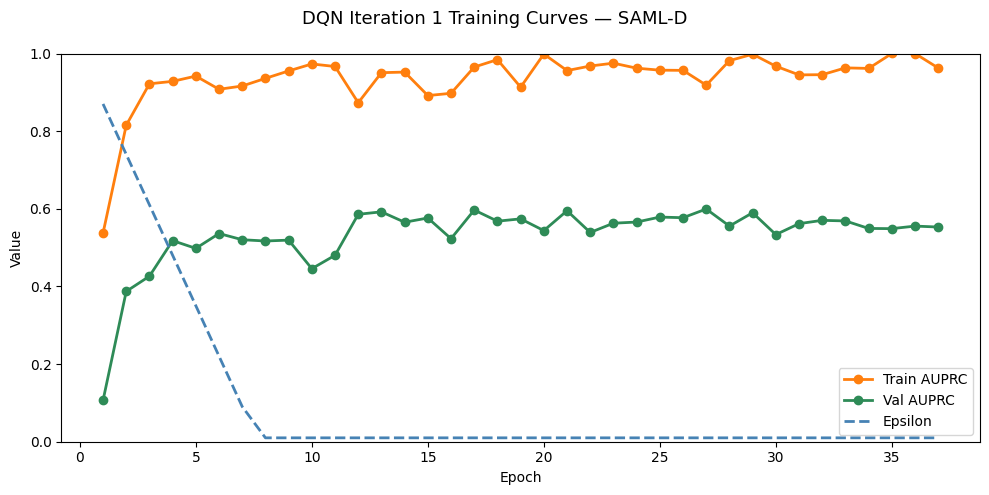

In [13]:
epochs_v1 = history_v1['epoch']

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('DQN Iteration 1 Training Curves — SAML-D', fontsize=13)

ax.plot(epochs_v1, history_v1['train_auprc'], color='#ff7f0e', lw=2, marker='o', label='Train AUPRC')
ax.plot(epochs_v1, history_v1['val_auprc'], color='seagreen', lw=2, marker='o', label='Val AUPRC')
ax.plot(epochs_v1, history_v1['epsilon'], color='steelblue', lw=2, linestyle='--', label='Epsilon')
ax.set_xlabel('Epoch')
ax.set_ylabel('Value')
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.savefig('dqn_v1_training_curves.png', dpi=150)
plt.show()

## 3.4 Evaluation

In [14]:
def evaluate(agent, X, y, split_name):
    scores = agent.get_scores(X)
    auprc  = average_precision_score(y, scores)
    print(f'\n{"="*50}')
    print(f'{split_name} AUPRC: {auprc:.4f}')
    return scores, auprc

# Load best weights for evaluation
agent_v1.q_network.load_state_dict(torch.load('./models/dqn_v1_best.pt', map_location=DEVICE))

val_scores_v1, val_auprc_v1 = evaluate(agent_v1, X_val_sc, y_val, 'DQN Iteration 1 - Validation')

print('\n' + '=' * 50)
print('COMPARISON - Iteration 1 Validation AUPRC')
print('=' * 50)
print(f'  DQN Iteration 1 (Lin) : {val_auprc_v1:.4f}')
print('=' * 50)
print('Test set evaluation is performed in the Comparison section.')


DQN Iteration 1 - Validation AUPRC: 0.5994

COMPARISON - Iteration 1 Validation AUPRC
  DQN Iteration 1 (Lin) : 0.5994
Test set evaluation is performed in the Comparison section.


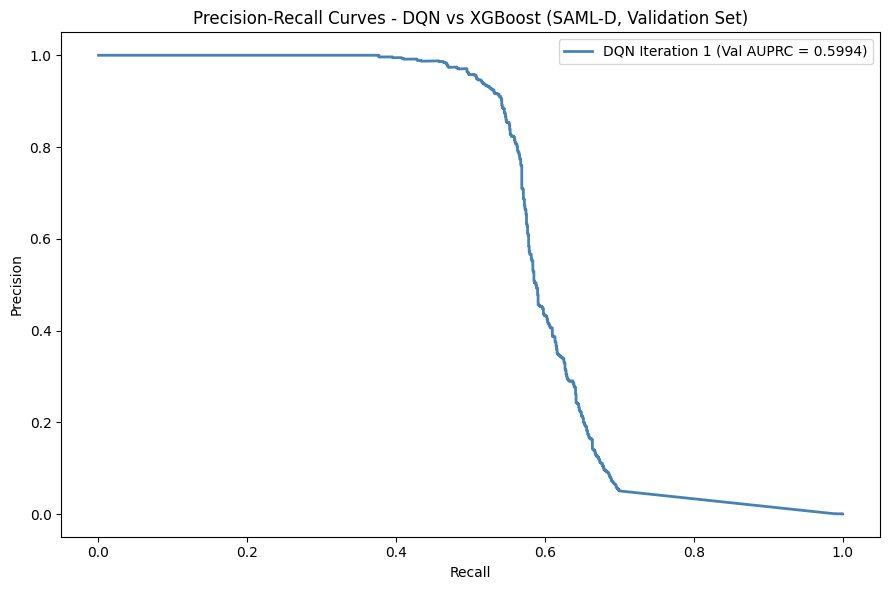

Saved: pr_curve_after_it1.png


In [15]:
import xgboost as xgb

# Load best XGBoost model — Iteration 3
xgb_model = xgb.XGBClassifier()
xgb_model.load_model('../XGBoost/xgboost_aml_optuna.json')
X_val_xgb = val_df.drop(columns=DROP_COLS).copy()
for col in X_val_xgb.select_dtypes('object').columns:
    X_val_xgb[col] = X_val_xgb[col].astype('category')
xgb_val_scores = xgb_model.predict_proba(X_val_xgb)[:, 1]
xgb_val_auprc  = average_precision_score(y_val, xgb_val_scores)

# PR curves
prec_xgb, rec_xgb, _ = precision_recall_curve(y_val, xgb_val_scores)
prec_v1,  rec_v1,  _ = precision_recall_curve(y_val, val_scores_v1)

plt.figure(figsize=(9, 6))
plt.plot(rec_v1, prec_v1, color='steelblue', lw=2, linestyle='-',
         label=f'DQN Iteration 1 (Val AUPRC = {val_auprc_v1:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - DQN vs XGBoost (SAML-D, Validation Set)')
plt.legend()
plt.tight_layout()
plt.savefig('pr_curve_after_it1.png', dpi=150)
plt.show()
print('Saved: pr_curve_after_it1.png')

---

# 4. Iteration 2: Zhinin-Vera et al. (2020)

Iteration 2 implements the reward function of [Zhinin-Vera et al. (2020)](#references), who empirically determine λ = 0.1 as the value producing the best classification accuracy on a credit card fraud dataset with imbalance ratio ρ = 0.001728. The discount factor is set to γ = 0.9 following [Zhinin-Vera et al. (2020)](#references). All other hyperparameters are identical to Iteration 1, isolating λ and γ as the only variables that differ between iterations.

## 4.1 Training Configuration

Hyperparameters identical to Iteration 1 except λ and γ, which follow [Zhinin-Vera et al. (2020)](#references).

In [16]:
# Iteration 2 — Zhinin-Vera et al. (2020): λ = 0.1, γ = 0.9
N_EPOCHS           = 100      # early stopping will terminate before this if converged
MEMORY_SIZE        = 6653396  # full training set buffer — Lin et al. principle
BATCH_SIZE         = 256      # scaled for SAML-D
GAMMA              = 0.9      # Zhinin-Vera et al. (2020)
LAMBDA             = 0.1      # Zhinin-Vera et al. (2020)
EPSILON_START      = 1.0      # Lin et al. (2019)
EPSILON_DECAY      = 0.00001  # scaled for SAML-D
EPSILON_MIN        = 0.01     # Lin et al. (2019)
LR                 = 0.00025  # Lin et al. (2019)
TRAIN_FREQ         = 10       # Qayoom et al. (2024)
TARGET_UPDATE_FREQ = 20       # Qayoom et al. (2024)

EARLY_STOPPING_PATIENCE  = 10
EARLY_STOPPING_MIN_DELTA = 0.001

print('Iteration 2 — Zhinin-Vera et al. (2020):')
print(f'  Lambda (λ)          : {LAMBDA}')
print(f'  Gamma (γ)           : {GAMMA}')
print(f'  Epochs (max)        : {N_EPOCHS}')
print(f'  Memory size         : {MEMORY_SIZE:,}')
print(f'  Batch size          : {BATCH_SIZE}')
print(f'  Epsilon start/decay/min: {EPSILON_START} / {EPSILON_DECAY} / {EPSILON_MIN}')
print(f'  Learning rate       : {LR}')
print(f'  Train freq          : {TRAIN_FREQ}')
print(f'  Target update freq  : {TARGET_UPDATE_FREQ}')
print(f'  Device              : {DEVICE}')

Iteration 2 — Zhinin-Vera et al. (2020):
  Lambda (λ)          : 0.1
  Gamma (γ)           : 0.9
  Epochs (max)        : 100
  Memory size         : 6,653,396
  Batch size          : 256
  Epsilon start/decay/min: 1.0 / 1e-05 / 0.01
  Learning rate       : 0.00025
  Train freq          : 10
  Target update freq  : 20
  Device              : cuda


## 4.2 Training Loop

In [17]:
# # Initialise agent and environment — Iteration 2
# agent_v2 = DQNAgent(
#     n_features         = N_FEATURES,
#     memory_size        = MEMORY_SIZE,
#     batch_size         = BATCH_SIZE,
#     gamma              = GAMMA,
#     epsilon            = EPSILON_START,
#     epsilon_decay      = EPSILON_DECAY,
#     epsilon_min        = EPSILON_MIN,
#     lr                 = LR,
#     train_freq         = TRAIN_FREQ,
#     target_update_freq = TARGET_UPDATE_FREQ,
# )

# history_v2 = {
#     'epoch'       : [],
#     'reward'      : [],
#     'loss'        : [],
#     'epsilon'     : [],
#     'train_auprc' : [],
#     'val_auprc'   : [],
#     'elapsed'     : [],
# }

# best_val_auprc_v2 = 0.0
# no_improve_count  = 0
# total_start       = time.time()

# for epoch in range(1, N_EPOCHS + 1):
#     epoch_start = time.time()

#     perm       = np.random.permutation(len(X_train_sc))
#     X_shuffled = X_train_sc[perm]
#     y_shuffled = y_train[perm]

#     total_reward = 0.0
#     losses       = []
#     step_count   = 0
#     CHUNK        = 512
#     n_chunks     = (len(X_shuffled) + CHUNK - 1) // CHUNK

#     for ci, i in enumerate(range(0, len(X_shuffled), CHUNK)):
#         states = X_shuffled[i:i+CHUNK]
#         labels = y_shuffled[i:i+CHUNK]

#         if random.random() < agent_v2.epsilon:
#             actions = np.random.randint(0, 2, size=len(states))
#         else:
#             with torch.no_grad():
#                 q = agent_v2.q_network(torch.FloatTensor(states).to(DEVICE))
#             actions = q.argmax(dim=1).cpu().numpy()

#         rewards = np.where(
#             actions == 1,
#             np.where(labels == 1, +1.0,    -LAMBDA),
#             np.where(labels == 1, -1.0,    +LAMBDA),
#         ).astype(np.float32)

#         total_reward += rewards.sum()

#         for j in range(len(states)):
#             done_flag  = (i + j + 1) >= len(X_shuffled)
#             next_state = X_shuffled[i+j+1] if not done_flag else np.zeros(N_FEATURES, dtype=np.float32)
#             agent_v2.memory.push(states[j], int(actions[j]), float(rewards[j]), next_state, done_flag)

#         agent_v2.decay_epsilon()
#         step_count += len(states)

#         if step_count % TRAIN_FREQ == 0:
#             loss = agent_v2.train_step()
#             if loss is not None:
#                 losses.append(loss)

#         if step_count % TARGET_UPDATE_FREQ == 0:
#             agent_v2.update_target()

#         if (ci + 1) % 1000 == 0:
#             elapsed = time.time() - epoch_start
#             pct     = (ci + 1) / n_chunks * 100
#             print(f'  Epoch {epoch} | {pct:.1f}% | {elapsed:.0f}s elapsed', end='\r')

#     # Evaluate train (fixed 50k sample) and validation
#     train_sample_idx = np.random.choice(len(X_train_sc), size=50000, replace=False)
#     train_scores     = agent_v2.get_scores(X_train_sc[train_sample_idx])
#     train_auprc      = average_precision_score(y_train[train_sample_idx], train_scores)

#     val_scores = agent_v2.get_scores(X_val_sc)
#     val_auprc  = average_precision_score(y_val, val_scores)

#     epoch_loss    = np.mean(losses) if losses else float('nan')
#     epoch_elapsed = time.time() - epoch_start

#     history_v2['epoch'].append(epoch)
#     history_v2['reward'].append(total_reward)
#     history_v2['loss'].append(epoch_loss)
#     history_v2['epsilon'].append(agent_v2.epsilon)
#     history_v2['train_auprc'].append(train_auprc)
#     history_v2['val_auprc'].append(val_auprc)
#     history_v2['elapsed'].append(epoch_elapsed)

#     if val_auprc > best_val_auprc_v2 + EARLY_STOPPING_MIN_DELTA:
#         best_val_auprc_v2 = val_auprc
#         no_improve_count  = 0
#         torch.save(agent_v2.q_network.state_dict(), 'dqn_v2_best.pt')
#         best_marker = ' <- best'
#     else:
#         no_improve_count += 1
#         best_marker = f' (no improve {no_improve_count}/{EARLY_STOPPING_PATIENCE})'

#     if epoch % 5 == 0:
#         torch.save(agent_v2.q_network.state_dict(), f'dqn_v2_epoch{epoch}.pt')
#         print(f'  Checkpoint saved: dqn_v2_epoch{epoch}.pt')

#     print(
#         f'Epoch {epoch:>2}/{N_EPOCHS} | '
#         f'Reward: {total_reward:>10.1f} | '
#         f'Loss: {epoch_loss:.4f} | '
#         f'Epsilon: {agent_v2.epsilon:.4f} | '
#         f'Train AUPRC: {train_auprc:.4f} | '
#         f'Val AUPRC: {val_auprc:.4f} | '
#         f'Time: {epoch_elapsed:.0f}s'
#         f'{best_marker}'
#     )

#     if no_improve_count >= EARLY_STOPPING_PATIENCE:
#         print(f'\nEarly stopping triggered — no improvement of >{EARLY_STOPPING_MIN_DELTA} '
#               f'for {EARLY_STOPPING_PATIENCE} consecutive epochs.')
#         break

# total_elapsed = time.time() - total_start
# print(f'\nIteration 2 complete in {total_elapsed/60:.1f} minutes')
# print(f'Best validation AUPRC: {best_val_auprc_v2:.4f} | Stopped at epoch: {epoch}')
# torch.save(agent_v2.q_network.state_dict(), 'dqn_v2_final.pt')
# print('Saved: dqn_v2_best.pt | dqn_v2_final.pt | dqn_v2_epoch5/10/...pt')

# # Save history to disk
# import json
# with open('history_v2.json', 'w') as f:
#     json.dump(history_v2, f)
# print('Saved: history_v2.json')

In [18]:
# ── LOAD MODEL AND HISTORY (run this instead of training loop if model already trained) ──
# Uncomment the block below to load saved model and history

import json
agent_v2 = DQNAgent(
    n_features         = N_FEATURES,
    memory_size        = MEMORY_SIZE,
    batch_size         = BATCH_SIZE,
    gamma              = GAMMA,
    epsilon            = EPSILON_MIN,
    epsilon_decay      = EPSILON_DECAY,
    epsilon_min        = EPSILON_MIN,
    lr                 = LR,
    train_freq         = TRAIN_FREQ,
    target_update_freq = TARGET_UPDATE_FREQ,
)
agent_v2.q_network.load_state_dict(torch.load('./models/dqn_v2_best.pt', map_location=DEVICE))
agent_v2.q_network.eval()
with open('./models/history_v2.json') as f:
    history_v2 = json.load(f)
print('Loaded: dqn_v2_best.pt and history_v2.json')

Loaded: dqn_v2_best.pt and history_v2.json


## 4.3 Training Curves

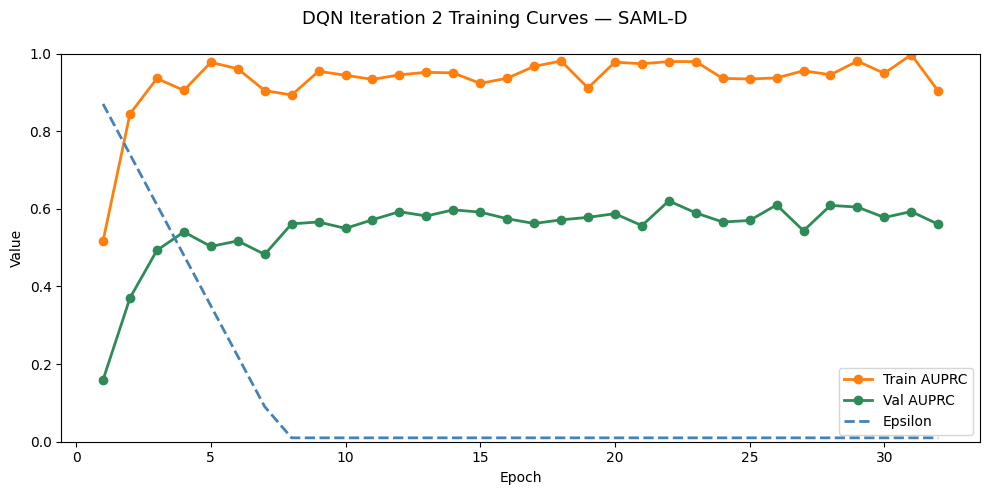

In [19]:
epochs_v2 = history_v2['epoch']

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('DQN Iteration 2 Training Curves — SAML-D', fontsize=13)

ax.plot(epochs_v2, history_v2['train_auprc'], color='#ff7f0e', lw=2, marker='o', label='Train AUPRC')
ax.plot(epochs_v2, history_v2['val_auprc'], color='seagreen', lw=2, marker='o', label='Val AUPRC')
ax.plot(epochs_v2, history_v2['epsilon'], color='steelblue', lw=2, linestyle='--', label='Epsilon')
ax.set_xlabel('Epoch')
ax.set_ylabel('Value')
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.savefig('dqn_v2_training_curves.png', dpi=150)
plt.show()

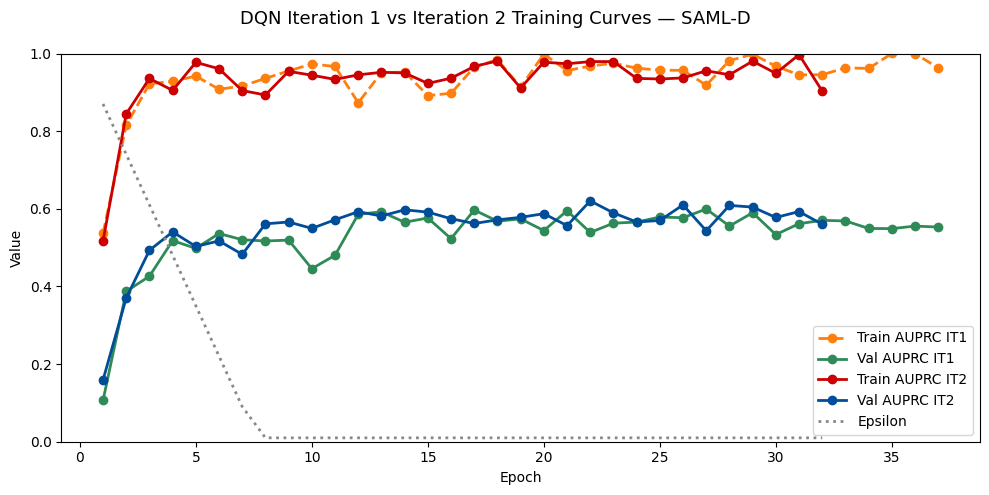

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('DQN Iteration 1 vs Iteration 2 Training Curves — SAML-D', fontsize=13)

ax.plot(epochs_v1, history_v1['train_auprc'], color='#ff7f0e', lw=2, linestyle='--', marker='o', label='Train AUPRC IT1')
ax.plot(epochs_v1, history_v1['val_auprc'], color='seagreen', lw=2, marker='o', label='Val AUPRC IT1')
ax.plot(epochs_v2, history_v2['train_auprc'], color='#cc0000', lw=2, marker='o', label='Train AUPRC IT2')
ax.plot(epochs_v2, history_v2['val_auprc'], color='#004d99', lw=2, marker='o', label='Val AUPRC IT2')
ax.plot(epochs_v2, history_v2['epsilon'], color='#888888', lw=2, linestyle=':', label='Epsilon')
ax.set_xlabel('Epoch')
ax.set_ylabel('Value')
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.savefig('dqn_v1_vs_v2_training_curves.png', dpi=150)
plt.show()

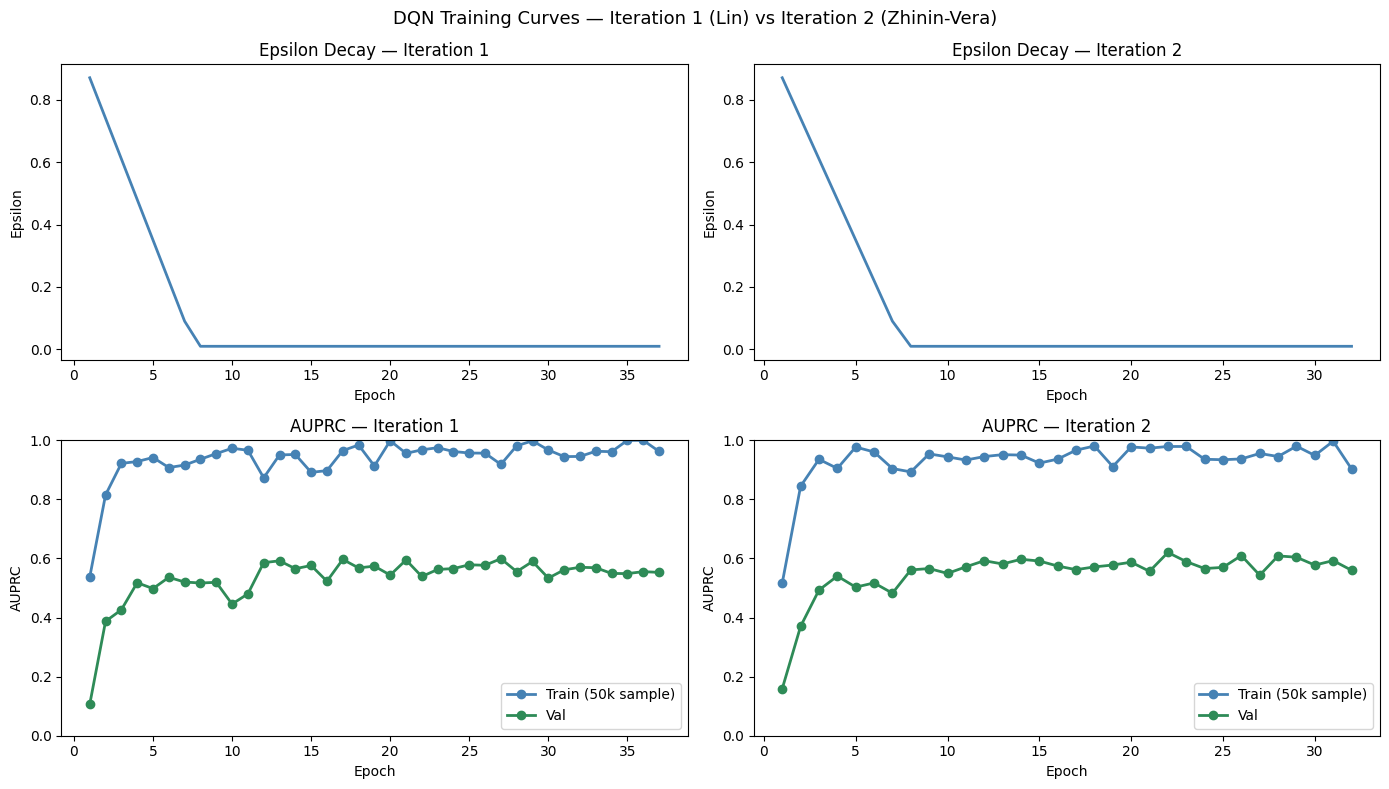

Saved: dqn_curves_it1_it2.png


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('DQN Training Curves — Iteration 1 (Lin) vs Iteration 2 (Zhinin-Vera)', fontsize=13)

# Epsilon
axes[0, 0].plot(history_v1['epoch'], history_v1['epsilon'], color='steelblue', lw=2)
axes[0, 0].set_title('Epsilon Decay — Iteration 1')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Epsilon')

axes[0, 1].plot(history_v2['epoch'], history_v2['epsilon'], color='steelblue', lw=2)
axes[0, 1].set_title('Epsilon Decay — Iteration 2')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Epsilon')

# AUPRC
axes[1, 0].plot(history_v1['epoch'], history_v1['train_auprc'], color='steelblue', lw=2, marker='o', label='Train (50k sample)')
axes[1, 0].plot(history_v1['epoch'], history_v1['val_auprc'], color='seagreen', lw=2, marker='o', label='Val')
axes[1, 0].set_title('AUPRC — Iteration 1')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUPRC')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()

axes[1, 1].plot(history_v2['epoch'], history_v2['train_auprc'], color='steelblue', lw=2, marker='o', label='Train (50k sample)')
axes[1, 1].plot(history_v2['epoch'], history_v2['val_auprc'], color='seagreen', lw=2, marker='o', label='Val')
axes[1, 1].set_title('AUPRC — Iteration 2')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('AUPRC')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('dqn_curves_it1_it2.png', dpi=150)
plt.show()
print('Saved: dqn_curves_it1_it2.png')

## 4.4 Evaluation
Looking at the training curves, it seems that both models seem to work really well on the trainset but aren't able to connverge on the validation set.

In [22]:
# Load best weights for evaluation
agent_v2.q_network.load_state_dict(torch.load('./models/dqn_v2_best.pt', map_location=DEVICE))

val_scores_v2, val_auprc_v2 = evaluate(agent_v2, X_val_sc, y_val, 'DQN Iteration 2 - Validation')

print('\n' + '=' * 50)
print('COMPARISON - All Iterations Validation AUPRC')
print('=' * 50)
print(f'  DQN Iteration 1 (Lin) : {val_auprc_v1:.4f}')
print(f'  DQN Iteration 2 (ZV)  : {val_auprc_v2:.4f}')
print('=' * 50)
print('Test set evaluation is performed in the Comparison section.')


DQN Iteration 2 - Validation AUPRC: 0.6203

COMPARISON - All Iterations Validation AUPRC
  DQN Iteration 1 (Lin) : 0.5994
  DQN Iteration 2 (ZV)  : 0.6203
Test set evaluation is performed in the Comparison section.


---

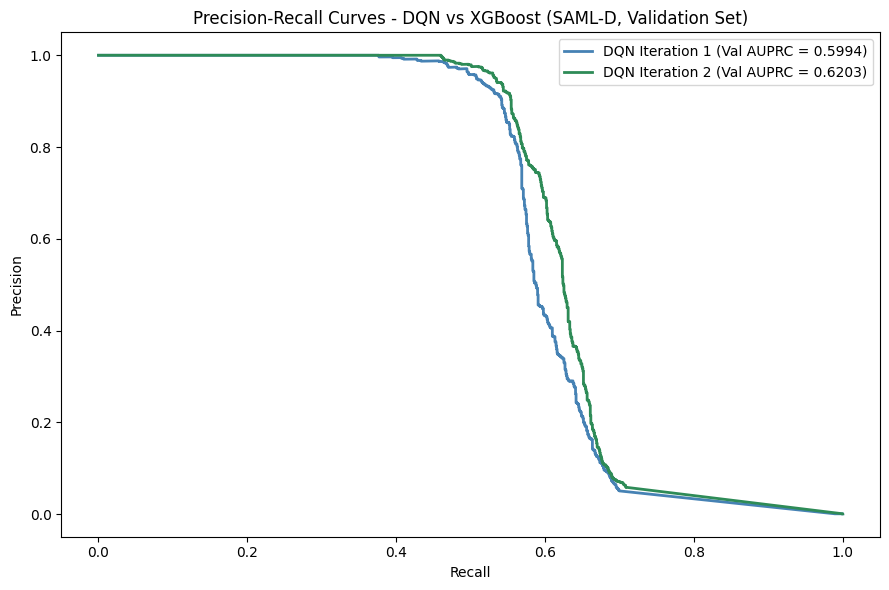

Saved: pr_curve_after_it2.png


In [23]:
import xgboost as xgb

# Load best XGBoost model — Iteration 3
xgb_model = xgb.XGBClassifier()
xgb_model.load_model('../XGBoost/xgboost_aml_optuna.json')
X_val_xgb = val_df.drop(columns=DROP_COLS).copy()
for col in X_val_xgb.select_dtypes('object').columns:
    X_val_xgb[col] = X_val_xgb[col].astype('category')
xgb_val_scores = xgb_model.predict_proba(X_val_xgb)[:, 1]
xgb_val_auprc  = average_precision_score(y_val, xgb_val_scores)

# PR curves
prec_xgb, rec_xgb, _ = precision_recall_curve(y_val, xgb_val_scores)
prec_v1,  rec_v1,  _ = precision_recall_curve(y_val, val_scores_v1)
prec_v2,  rec_v2,  _ = precision_recall_curve(y_val, val_scores_v2)

plt.figure(figsize=(9, 6))
plt.plot(rec_v1, prec_v1, color='steelblue', lw=2, linestyle='-',
         label=f'DQN Iteration 1 (Val AUPRC = {val_auprc_v1:.4f})')
plt.plot(rec_v2, prec_v2, color='seagreen', lw=2,
         label=f'DQN Iteration 2 (Val AUPRC = {val_auprc_v2:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - DQN vs XGBoost (SAML-D, Validation Set)')
plt.legend()
plt.tight_layout()
plt.savefig('pr_curve_after_it2.png', dpi=150)
plt.show()
print('Saved: pr_curve_after_it2.png')

---

# 5. Iteration 3: Zhinin-Vera et al. (2020) — Adjusted Epsilon Decay

Iteration 2 achieved a higher validation AUPRC than Iteration 1 (0.6203 vs 0.5994), establishing the Zhinin-Vera et al. (2020) reward function with λ = 0.1 and γ = 0.9 as the stronger configuration. Iteration 3 therefore builds on Iteration 2, keeping λ = 0.1 and γ = 0.9 unchanged, and investigates whether the generalisation gap can be reduced by adjusting the epsilon decay rate.

Analysis of the Iteration 2 training curves revealed that epsilon decayed to its minimum of 0.01 by epoch 8, leaving the agent in pure exploitation mode for the remaining 29 epochs. During this exploitation phase, train AUPRC frequently reached 0.95-1.0 while val AUPRC plateaued around 0.55-0.62, a clear sign of overfitting caused by the agent updating weights aggressively on a fixed policy with no exploration to correct it.

The root cause is a mismatch between the epsilon decay rate and the dataset size. The original decay rate of 0.00001 was not designed for a dataset of this scale. At this rate epsilon reaches its minimum after only approximately 99,000 steps:

```md
steps_to_min = (epsilon_start - epsilon_min) / epsilon_decay
             = (1.0 - 0.01) / 0.00001
             = 99,000 steps
```

In the training loop, epsilon is decayed once per 512 transactions processed. With 6,653,396 training transactions per epoch, this results in approximately 13,000 decay steps per epoch. At a decay rate of 0.00001 per step, epsilon therefore reaches its minimum after 99,000 / 13,000 ≈ 7.6 epochs, consistent with the observed behaviour in Iteration 2 where epsilon reached its minimum of 0.01 during epoch 8.

Iteration 3 keeps all hyperparameters identical to Iteration 2 but slows the epsilon decay so that exploration continues until epoch 20. Since epsilon reached its minimum at epoch 8 in Iteration 2, epoch 20 was chosen as a straightforward doubling to test whether more exploration time improves generalisation. The target decay rate is calculated as:

```md
chunks_per_epoch  = ceil(6,653,396 / 512) = 12,994.914... ≈ 12,995
target_epochs     = 20
total_steps       = 12,995 * 20 = 259,900
epsilon_decay     = (1.0 - 0.01) / 259,900 = 0.000003809... ≈ 0.0000038
```

This gives the agent roughly 2.5x more exploration time before committing to a policy, while keeping everything else, λ, γ, architecture, buffer size, learning rate, identical to Iteration 2 to isolate epsilon decay as the only variable.

## 5.1 Training Configuration

In [24]:
import math

# Iteration 3 — Zhinin-Vera et al. (2020) + adjusted epsilon decay
# All parameters identical to Iteration 2 except EPSILON_DECAY
N_EPOCHS           = 100
MEMORY_SIZE        = 6653396
BATCH_SIZE         = 256
GAMMA              = 0.9      # Zhinin-Vera et al. (2020)
LAMBDA             = 0.1      # Zhinin-Vera et al. (2020)
EPSILON_START      = 1.0      # Lin et al. (2019)
EPSILON_MIN        = 0.01     # Lin et al. (2019)
LR                 = 0.00025  # Lin et al. (2019)
TRAIN_FREQ         = 10       # Qayoom et al. (2024)
TARGET_UPDATE_FREQ = 20       # Qayoom et al. (2024)

# Calculate epsilon decay to reach minimum at epoch 20
CHUNKS_PER_EPOCH = math.ceil(6_653_396 / 512)
TARGET_EPOCH     = 20
EPSILON_DECAY    = (EPSILON_START - EPSILON_MIN) / (CHUNKS_PER_EPOCH * TARGET_EPOCH)

EARLY_STOPPING_PATIENCE  = 10
EARLY_STOPPING_MIN_DELTA = 0.001

print('Iteration 3 — Zhinin-Vera et al. (2020) + adjusted epsilon decay:')
print(f'  Lambda (λ)               : {LAMBDA}')
print(f'  Gamma (γ)                : {GAMMA}')
print(f'  Epochs (max)             : {N_EPOCHS}')
print(f'  Memory size              : {MEMORY_SIZE:,}')
print(f'  Batch size               : {BATCH_SIZE}')
print(f'  Epsilon start            : {EPSILON_START}')
print(f'  Epsilon decay (computed) : {EPSILON_DECAY:.8f}')
print(f'  Epsilon min              : {EPSILON_MIN}')
print(f'  Epsilon reaches min at   : epoch {TARGET_EPOCH} (approx)')
print(f'  Learning rate            : {LR}')
print(f'  Train freq               : {TRAIN_FREQ}')
print(f'  Target update freq       : {TARGET_UPDATE_FREQ}')
print(f'  Device                   : {DEVICE}')

Iteration 3 — Zhinin-Vera et al. (2020) + adjusted epsilon decay:
  Lambda (λ)               : 0.1
  Gamma (γ)                : 0.9
  Epochs (max)             : 100
  Memory size              : 6,653,396
  Batch size               : 256
  Epsilon start            : 1.0
  Epsilon decay (computed) : 0.00000381
  Epsilon min              : 0.01
  Epsilon reaches min at   : epoch 20 (approx)
  Learning rate            : 0.00025
  Train freq               : 10
  Target update freq       : 20
  Device                   : cuda


## 5.2 Training Loop

In [25]:
# # Initialise agent — Iteration 3
# agent_v3 = DQNAgent(
#     n_features         = N_FEATURES,
#     memory_size        = MEMORY_SIZE,
#     batch_size         = BATCH_SIZE,
#     gamma              = GAMMA,
#     epsilon            = EPSILON_START,
#     epsilon_decay      = EPSILON_DECAY,
#     epsilon_min        = EPSILON_MIN,
#     lr                 = LR,
#     train_freq         = TRAIN_FREQ,
#     target_update_freq = TARGET_UPDATE_FREQ,
# )

# history_v3 = {
#     'epoch'       : [],
#     'reward'      : [],
#     'loss'        : [],
#     'epsilon'     : [],
#     'train_auprc' : [],
#     'val_auprc'   : [],
#     'elapsed'     : [],
# }

# best_val_auprc_v3 = 0.0
# no_improve_count  = 0
# total_start       = time.time()

# for epoch in range(1, N_EPOCHS + 1):
#     epoch_start = time.time()

#     perm       = np.random.permutation(len(X_train_sc))
#     X_shuffled = X_train_sc[perm]
#     y_shuffled = y_train[perm]

#     total_reward = 0.0
#     losses       = []
#     step_count   = 0
#     CHUNK        = 512
#     n_chunks     = (len(X_shuffled) + CHUNK - 1) // CHUNK

#     for ci, i in enumerate(range(0, len(X_shuffled), CHUNK)):
#         states = X_shuffled[i:i+CHUNK]
#         labels = y_shuffled[i:i+CHUNK]

#         if random.random() < agent_v3.epsilon:
#             actions = np.random.randint(0, 2, size=len(states))
#         else:
#             with torch.no_grad():
#                 q = agent_v3.q_network(torch.FloatTensor(states).to(DEVICE))
#             actions = q.argmax(dim=1).cpu().numpy()

#         rewards = np.where(
#             actions == 1,
#             np.where(labels == 1, +1.0,    -LAMBDA),
#             np.where(labels == 1, -1.0,    +LAMBDA),
#         ).astype(np.float32)

#         total_reward += rewards.sum()

#         for j in range(len(states)):
#             done_flag  = (i + j + 1) >= len(X_shuffled)
#             next_state = X_shuffled[i+j+1] if not done_flag else np.zeros(N_FEATURES, dtype=np.float32)
#             agent_v3.memory.push(states[j], int(actions[j]), float(rewards[j]), next_state, done_flag)

#         agent_v3.decay_epsilon()
#         step_count += len(states)

#         if step_count % TRAIN_FREQ == 0:
#             loss = agent_v3.train_step()
#             if loss is not None:
#                 losses.append(loss)

#         if step_count % TARGET_UPDATE_FREQ == 0:
#             agent_v3.update_target()

#         if (ci + 1) % 1000 == 0:
#             elapsed = time.time() - epoch_start
#             pct     = (ci + 1) / n_chunks * 100
#             print(f'  Epoch {epoch} | {pct:.1f}% | {elapsed:.0f}s elapsed', end='\r')

#     # Evaluate train (fixed 50k sample) and validation
#     train_sample_idx = np.random.choice(len(X_train_sc), size=50000, replace=False)
#     train_scores     = agent_v3.get_scores(X_train_sc[train_sample_idx])
#     train_auprc      = average_precision_score(y_train[train_sample_idx], train_scores)

#     val_scores = agent_v3.get_scores(X_val_sc)
#     val_auprc  = average_precision_score(y_val, val_scores)

#     epoch_loss    = np.mean(losses) if losses else float('nan')
#     epoch_elapsed = time.time() - epoch_start

#     history_v3['epoch'].append(epoch)
#     history_v3['reward'].append(total_reward)
#     history_v3['loss'].append(epoch_loss)
#     history_v3['epsilon'].append(agent_v3.epsilon)
#     history_v3['train_auprc'].append(train_auprc)
#     history_v3['val_auprc'].append(val_auprc)
#     history_v3['elapsed'].append(epoch_elapsed)

#     if val_auprc > best_val_auprc_v3 + EARLY_STOPPING_MIN_DELTA:
#         best_val_auprc_v3 = val_auprc
#         no_improve_count  = 0
#         torch.save(agent_v3.q_network.state_dict(), 'dqn_v3_best.pt')
#         best_marker = ' <- best'
#     else:
#         no_improve_count += 1
#         best_marker = f' (no improve {no_improve_count}/{EARLY_STOPPING_PATIENCE})'

#     if epoch % 5 == 0:
#         torch.save(agent_v3.q_network.state_dict(), f'dqn_v3_epoch{epoch}.pt')
#         print(f'  Checkpoint saved: dqn_v3_epoch{epoch}.pt')

#     print(
#         f'Epoch {epoch:>2}/{N_EPOCHS} | '
#         f'Reward: {total_reward:>10.1f} | '
#         f'Loss: {epoch_loss:.4f} | '
#         f'Epsilon: {agent_v3.epsilon:.6f} | '
#         f'Train AUPRC: {train_auprc:.4f} | '
#         f'Val AUPRC: {val_auprc:.4f} | '
#         f'Time: {epoch_elapsed:.0f}s'
#         f'{best_marker}'
#     )

#     if no_improve_count >= EARLY_STOPPING_PATIENCE:
#         print(f'\nEarly stopping triggered — no improvement of >{EARLY_STOPPING_MIN_DELTA} '
#               f'for {EARLY_STOPPING_PATIENCE} consecutive epochs.')
#         break

# total_elapsed = time.time() - total_start
# print(f'\nIteration 3 complete in {total_elapsed/60:.1f} minutes')
# print(f'Best validation AUPRC: {best_val_auprc_v3:.4f} | Stopped at epoch: {epoch}')
# torch.save(agent_v3.q_network.state_dict(), 'dqn_v3_final.pt')
# print('Saved: dqn_v3_best.pt | dqn_v3_final.pt | dqn_v3_epoch5/10/...pt')

# # Save history to disk
# import json
# with open('history_v3.json', 'w') as f:
#     json.dump(history_v3, f)
# print('Saved: history_v3.json')

In [26]:
# ── LOAD MODEL AND HISTORY (run this instead of training loop if model already trained) ──
# Uncomment the block below to load saved model and history

import json
agent_v3 = DQNAgent(
    n_features         = N_FEATURES,
    memory_size        = MEMORY_SIZE,
    batch_size         = BATCH_SIZE,
    gamma              = GAMMA,
    epsilon            = EPSILON_MIN,
    epsilon_decay      = EPSILON_DECAY,
    epsilon_min        = EPSILON_MIN,
    lr                 = LR,
    train_freq         = TRAIN_FREQ,
    target_update_freq = TARGET_UPDATE_FREQ,
)
agent_v3.q_network.load_state_dict(torch.load('models/dqn_v3_best.pt', map_location=DEVICE))
agent_v3.q_network.eval()
with open('models/history_v3.json') as f:
    history_v3 = json.load(f)
print('Loaded: dqn_v3_best.pt and history_v3.json')

Loaded: dqn_v3_best.pt and history_v3.json


## 5.3 Training Curves

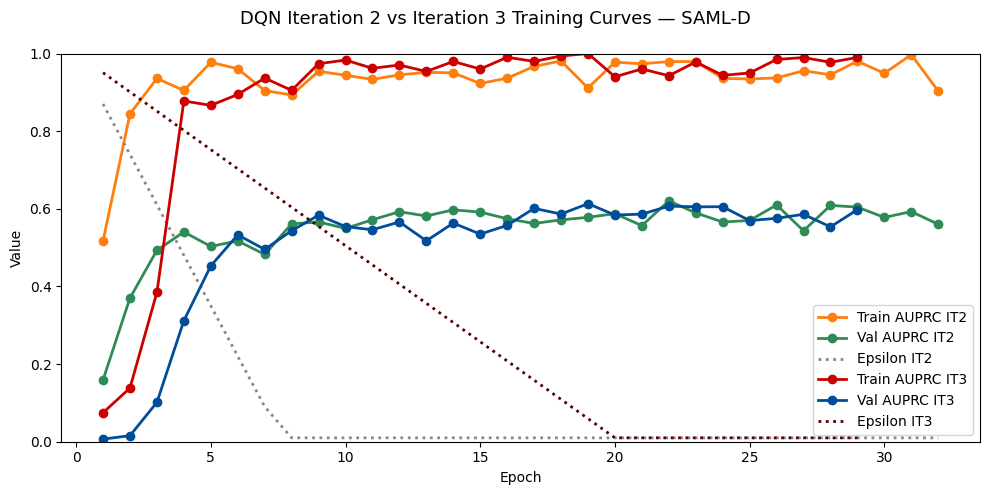

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('DQN Iteration 2 vs Iteration 3 Training Curves — SAML-D', fontsize=13)

epochs_v3 = history_v3['epoch']

ax.plot(epochs_v2, history_v2['train_auprc'], color='#ff7f0e', lw=2, linestyle='-', marker='o', label='Train AUPRC IT2')
ax.plot(epochs_v2, history_v2['val_auprc'], color='seagreen', lw=2, marker='o', label='Val AUPRC IT2')
ax.plot(epochs_v2, history_v2['epsilon'], color='#888888', lw=2, linestyle=':', label='Epsilon IT2')
ax.plot(epochs_v3, history_v3['train_auprc'], color='#cc0000', lw=2, marker='o', label='Train AUPRC IT3')
ax.plot(epochs_v3, history_v3['val_auprc'], color='#004d99', lw=2, marker='o', label='Val AUPRC IT3')
ax.plot(epochs_v3, history_v3['epsilon'], color='#550000', lw=2, linestyle=':', label='Epsilon IT3')
ax.set_xlabel('Epoch')
ax.set_ylabel('Value')
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.savefig('dqn_v2_vs_v3_training_curves.png', dpi=150)
plt.show()

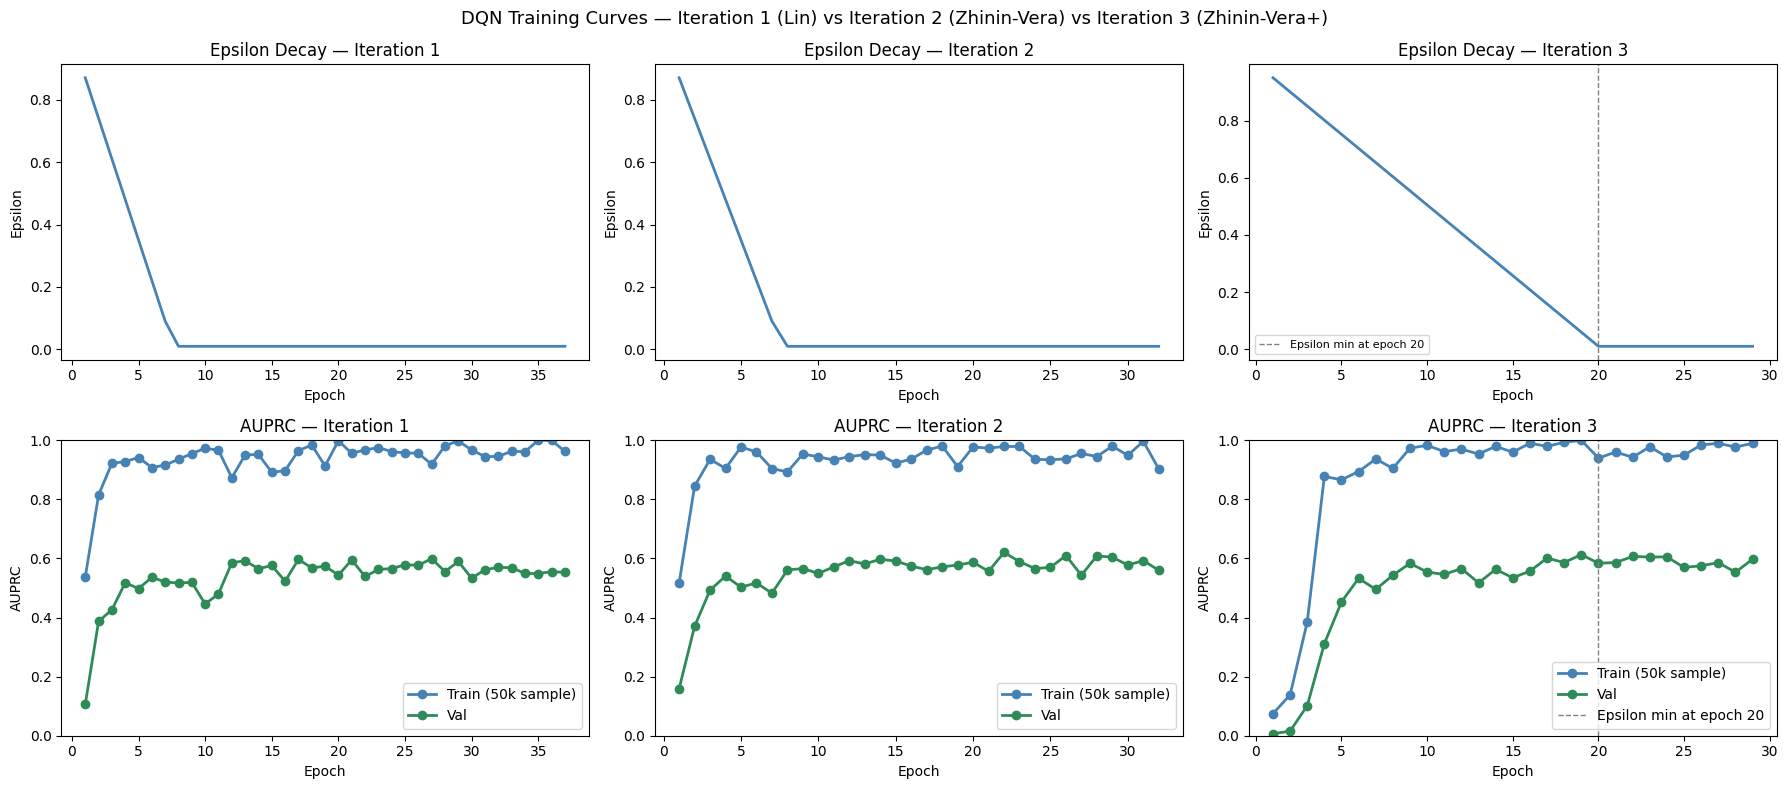

Saved: dqn_curves_it1_it2_it3.png


In [28]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle('DQN Training Curves — Iteration 1 (Lin) vs Iteration 2 (Zhinin-Vera) vs Iteration 3 (Zhinin-Vera+)', fontsize=13)

# Epsilon
axes[0, 0].plot(history_v1['epoch'], history_v1['epsilon'], color='steelblue', lw=2)
axes[0, 0].set_title('Epsilon Decay — Iteration 1')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Epsilon')

axes[0, 1].plot(history_v2['epoch'], history_v2['epsilon'], color='steelblue', lw=2)
axes[0, 1].set_title('Epsilon Decay — Iteration 2')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Epsilon')

axes[0, 2].plot(history_v3['epoch'], history_v3['epsilon'], color='steelblue', lw=2)
axes[0, 2].axvline(x=20, color='grey', lw=1, linestyle='--', label='Epsilon min at epoch 20')
axes[0, 2].set_title('Epsilon Decay — Iteration 3')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Epsilon')
axes[0, 2].legend(fontsize=8)

# AUPRC
axes[1, 0].plot(history_v1['epoch'], history_v1['train_auprc'], color='steelblue', lw=2, marker='o', label='Train (50k sample)')
axes[1, 0].plot(history_v1['epoch'], history_v1['val_auprc'], color='seagreen', lw=2, marker='o', label='Val')
axes[1, 0].set_title('AUPRC — Iteration 1')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUPRC')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()

axes[1, 1].plot(history_v2['epoch'], history_v2['train_auprc'], color='steelblue', lw=2, marker='o', label='Train (50k sample)')
axes[1, 1].plot(history_v2['epoch'], history_v2['val_auprc'], color='seagreen', lw=2, marker='o', label='Val')
axes[1, 1].set_title('AUPRC — Iteration 2')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('AUPRC')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()

axes[1, 2].plot(history_v3['epoch'], history_v3['train_auprc'], color='steelblue', lw=2, marker='o', label='Train (50k sample)')
axes[1, 2].plot(history_v3['epoch'], history_v3['val_auprc'], color='seagreen', lw=2, marker='o', label='Val')
axes[1, 2].axvline(x=20, color='grey', lw=1, linestyle='--', label='Epsilon min at epoch 20')
axes[1, 2].set_title('AUPRC — Iteration 3')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('AUPRC')
axes[1, 2].set_ylim(0, 1)
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('dqn_curves_it1_it2_it3.png', dpi=150)
plt.show()
print('Saved: dqn_curves_it1_it2_it3.png')

## 5.4 Evaluation
The table below summarises the validation AUPRC across all three DQN iterations alongside the XGBoost benchmark. 

| Model | Val AUPRC |
|---|---|
| XGBoost Iteration 2 (benchmark) | 0.9275 |
| DQN Iteration 1 (Lin et al., λ = ρ) | 0.5994 |
| DQN Iteration 2 (Zhinin-Vera, λ = 0.1) | 0.6203 |
| DQN Iteration 3 (Zhinin-Vera, adjusted ε decay) | 0.6132 |

Analysis of the training curves reveals that the train/val AUPRC gap emerges as early as epoch 3-5 across all iterations, with train AUPRC reaching 0.95-1.0 while val AUPRC plateaus around 0.55-0.65. This pattern is consistent across different reward functions and epsilon decay schedules, indicating that the overfitting is not caused by the reward design or exploration strategy but clearly by a different factor.

A common fix for overfitting neural networks is to add dropout layers. [Srivastava et al. (2014)](#references) introduce dropout as a regularisation technique that randomly drops units during training, preventing neurons from co-adapting and forcing the network to learn more generalised representations. Since Iteration 3 did not improve over Iteration 2, the adjusted epsilon decay is reverted and Iteration 4 builds directly on Iteration 2, adding dropout to the Q-network as the only change to test whether this reduces the train/val gap and improves validation AUPRC.


In [29]:
agent_v3.q_network.load_state_dict(torch.load('models/dqn_v3_best.pt', map_location=DEVICE))

val_scores_v3, val_auprc_v3 = evaluate(agent_v3, X_val_sc, y_val, 'DQN Iteration 3 - Validation')

print('\n' + '=' * 60)
print('COMPARISON - All Iterations Validation AUPRC')
print('=' * 60)
print(f'  DQN Iteration 1 (Lin) : {val_auprc_v1:.4f}')
print(f'  DQN Iteration 2 (ZV)  : {val_auprc_v2:.4f}')
print(f'  DQN Iteration 3 (ZV+) : {val_auprc_v3:.4f}')
print('=' * 60)
print('Test set evaluation is performed in the Comparison section.')


DQN Iteration 3 - Validation AUPRC: 0.6132

COMPARISON - All Iterations Validation AUPRC
  DQN Iteration 1 (Lin) : 0.5994
  DQN Iteration 2 (ZV)  : 0.6203
  DQN Iteration 3 (ZV+) : 0.6132
Test set evaluation is performed in the Comparison section.


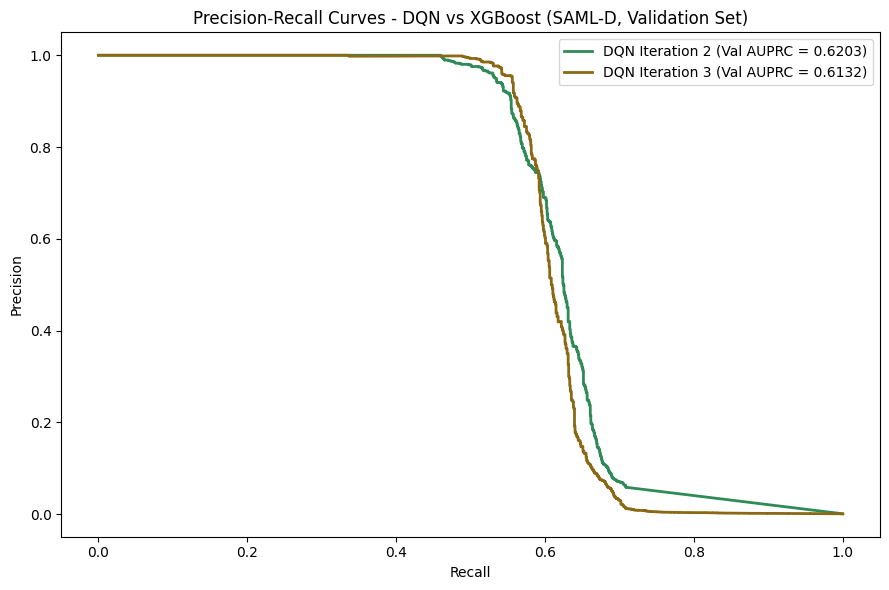

In [30]:
import xgboost as xgb

# Load best XGBoost model — Iteration 3
xgb_model = xgb.XGBClassifier()
xgb_model.load_model('../XGBoost/xgboost_aml_optuna.json')
X_val_xgb = val_df.drop(columns=DROP_COLS).copy()
for col in X_val_xgb.select_dtypes('object').columns:
    X_val_xgb[col] = X_val_xgb[col].astype('category')
xgb_val_scores = xgb_model.predict_proba(X_val_xgb)[:, 1]
xgb_val_auprc  = average_precision_score(y_val, xgb_val_scores)

# PR curves
prec_xgb, rec_xgb, _ = precision_recall_curve(y_val, xgb_val_scores)
prec_v1,  rec_v1,  _ = precision_recall_curve(y_val, val_scores_v1)
prec_v2,  rec_v2,  _ = precision_recall_curve(y_val, val_scores_v2)
prec_v3,  rec_v3,  _ = precision_recall_curve(y_val, val_scores_v3)

plt.figure(figsize=(9, 6))
plt.plot(rec_v2, prec_v2, color='seagreen', lw=2, label=f'DQN Iteration 2 (Val AUPRC = {val_auprc_v2:.4f})')
plt.plot(rec_v3, prec_v3, color='#8b6914', lw=2, linestyle='-',
         label=f'DQN Iteration 3 (Val AUPRC = {val_auprc_v3:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - DQN vs XGBoost (SAML-D, Validation Set)')
plt.legend()
plt.tight_layout()
plt.savefig('pr_curve_after_it3.png', dpi=150)
plt.show()

---

# 6. Iteration 4: Zhinin-Vera et al. (2020) — Dropout Regularisation

Iteration 4 builds directly on Iteration 2, keeping all hyperparameters identical (λ = 0.1, γ = 0.9, ε decay = 0.00001) and adds dropout layers to the Q-network following [Srivastava et al. (2014)](#references). Dropout randomly sets a fraction of neuron activations to zero during each forward pass, preventing neurons from co-adapting and forcing the network to learn more generalised representations.

[Srivastava et al. (2014)](#references) recommend a dropout rate of p = 0.5 for hidden units as close to optimal for a wide range of networks and tasks. Dropout is applied to all four hidden layers with p = 0.5.

The input layer is left without dropout. [Srivastava et al. (2014)](#references) apply dropout to input layers with p = 0.8 in experiments on image and speech data, where inputs are dense continuous values. In this research the input layer consists of 91 features combining standardised continuous values and binary one-hot encoded columns. One-hot encoded features are already sparse by nature, taking values of 0 for all but one category per categorical variable. Applying dropout to these features would randomly zero out already sparse inputs, risking the loss of the only active feature in a one-hot group entirely. Dropout is therefore applied to the hidden layers only.

## 6.1 Training Configuration

In [31]:
# Iteration 4 — Zhinin-Vera et al. (2020) + dropout regularisation
# All parameters identical to Iteration 2
N_EPOCHS           = 100
MEMORY_SIZE        = 6653396
BATCH_SIZE         = 256
GAMMA              = 0.9      # Zhinin-Vera et al. (2020)
LAMBDA             = 0.1      # Zhinin-Vera et al. (2020)
EPSILON_START      = 1.0      # Lin et al. (2019)
EPSILON_DECAY      = 0.00001  # scaled for SAML-D
EPSILON_MIN        = 0.01     # Lin et al. (2019)
LR                 = 0.00025  # Lin et al. (2019)
TRAIN_FREQ         = 10       # Qayoom et al. (2024)
TARGET_UPDATE_FREQ = 20       # Qayoom et al. (2024)
DROPOUT_RATE       = 0.5      # Srivastava et al. (2014)

EARLY_STOPPING_PATIENCE  = 10
EARLY_STOPPING_MIN_DELTA = 0.001

print("Iteration 4 — Zhinin-Vera et al. (2020) + dropout:")
print(f"  Lambda (λ)          : {LAMBDA}")
print(f"  Gamma (γ)           : {GAMMA}")
print(f"  Dropout rate        : {DROPOUT_RATE}")
print(f"  Epochs (max)        : {N_EPOCHS}")
print(f"  Memory size         : {MEMORY_SIZE:,}")
print(f"  Batch size          : {BATCH_SIZE}")
print(f"  Epsilon start/decay/min: {EPSILON_START} / {EPSILON_DECAY} / {EPSILON_MIN}")
print(f"  Learning rate       : {LR}")
print(f"  Train freq          : {TRAIN_FREQ}")
print(f"  Target update freq  : {TARGET_UPDATE_FREQ}")
print(f"  Device              : {DEVICE}")

Iteration 4 — Zhinin-Vera et al. (2020) + dropout:
  Lambda (λ)          : 0.1
  Gamma (γ)           : 0.9
  Dropout rate        : 0.5
  Epochs (max)        : 100
  Memory size         : 6,653,396
  Batch size          : 256
  Epsilon start/decay/min: 1.0 / 1e-05 / 0.01
  Learning rate       : 0.00025
  Train freq          : 10
  Target update freq  : 20
  Device              : cuda


## 6.2 Q-Network with Dropout

The Q-network architecture follows [Qayoom et al. (2024)](#references) with dropout applied to all hidden layers with p = 0.5 following [Srivastava et al. (2014)](#references):

| Layer | Neurons | Activation | Dropout |
|---|---|---|---|
| Input | `N_FEATURES` | - | - |
| Hidden 1 | 124 | ReLU | 0.5 |
| Hidden 2 | 62 | ReLU | 0.5 |
| Hidden 3 | 31 | Tanh | 0.5 |
| Hidden 4 | 15 | Linear | 0.5 |
| Output | 2 | Linear | - |

In [32]:
class QNetworkDropout(nn.Module):
    """
    Q-Network with dropout regularisation following Srivastava et al. (2014).
    Architecture follows Qayoom et al. (2024).
    Dropout p = 0.5 applied to all hidden layers.
    Input layer left without dropout due to sparse one-hot encoded features.
    """

    def __init__(self, n_features: int, dropout_rate: float = 0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 124), nn.ReLU(),   nn.Dropout(dropout_rate),
            nn.Linear(124, 62),         nn.ReLU(),   nn.Dropout(dropout_rate),
            nn.Linear(62,  31),         nn.Tanh(),   nn.Dropout(dropout_rate),
            nn.Linear(31,  15),                      nn.Dropout(dropout_rate),
            nn.Linear(15,   2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class DQNAgentDropout(DQNAgent):
    """
    DQN agent using QNetworkDropout instead of QNetwork.
    All other behaviour identical to DQNAgent.
    """

    def __init__(self, n_features, dropout_rate=0.5, **kwargs):
        super().__init__(n_features, **kwargs)
        self.q_network      = QNetworkDropout(n_features, dropout_rate).to(DEVICE)
        self.target_network = QNetworkDropout(n_features, dropout_rate).to(DEVICE)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()
        self.optimiser = optim.Adam(self.q_network.parameters(), lr=kwargs.get('lr', 0.00025))

# Verify architecture
dummy_net = QNetworkDropout(N_FEATURES, DROPOUT_RATE)
print(dummy_net)
print(f'Input size  : {N_FEATURES}')
print('DQNAgentDropout defined.')

QNetworkDropout(
  (net): Sequential(
    (0): Linear(in_features=91, out_features=124, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=124, out_features=62, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=62, out_features=31, bias=True)
    (7): Tanh()
    (8): Dropout(p=0.5, inplace=False)
    (9): Linear(in_features=31, out_features=15, bias=True)
    (10): Dropout(p=0.5, inplace=False)
    (11): Linear(in_features=15, out_features=2, bias=True)
  )
)
Input size  : 91
DQNAgentDropout defined.


## 6.3 Training Loop

In [33]:
# # Initialise agent - Iteration 4
# agent_v4 = DQNAgentDropout(
#     n_features         = N_FEATURES,
#     dropout_rate       = DROPOUT_RATE,
#     memory_size        = MEMORY_SIZE,
#     batch_size         = BATCH_SIZE,
#     gamma              = GAMMA,
#     epsilon            = EPSILON_START,
#     epsilon_decay      = EPSILON_DECAY,
#     epsilon_min        = EPSILON_MIN,
#     lr                 = LR,
#     train_freq         = TRAIN_FREQ,
#     target_update_freq = TARGET_UPDATE_FREQ,
# )

# history_v4 = {
#     'epoch'       : [],
#     'reward'      : [],
#     'loss'        : [],
#     'epsilon'     : [],
#     'train_auprc' : [],
#     'val_auprc'   : [],
#     'elapsed'     : [],
# }

# best_val_auprc_v4 = 0.0
# no_improve_count  = 0
# total_start       = time.time()

# for epoch in range(1, N_EPOCHS + 1):
#     epoch_start = time.time()

#     perm       = np.random.permutation(len(X_train_sc))
#     X_shuffled = X_train_sc[perm]
#     y_shuffled = y_train[perm]

#     total_reward = 0.0
#     losses       = []
#     step_count   = 0
#     CHUNK        = 512
#     n_chunks     = (len(X_shuffled) + CHUNK - 1) // CHUNK

#     for ci, i in enumerate(range(0, len(X_shuffled), CHUNK)):
#         states = X_shuffled[i:i+CHUNK]
#         labels = y_shuffled[i:i+CHUNK]

#         if random.random() < agent_v4.epsilon:
#             actions = np.random.randint(0, 2, size=len(states))
#         else:
#             with torch.no_grad():
#                 q = agent_v4.q_network(torch.FloatTensor(states).to(DEVICE))
#             actions = q.argmax(dim=1).cpu().numpy()

#         rewards = np.where(
#             actions == 1,
#             np.where(labels == 1, +1.0, -LAMBDA),
#             np.where(labels == 1, -1.0, +LAMBDA),
#         ).astype(np.float32)

#         total_reward += rewards.sum()

#         for j in range(len(states)):
#             done_flag  = (i + j + 1) >= len(X_shuffled)
#             next_state = X_shuffled[i+j+1] if not done_flag else np.zeros(N_FEATURES, dtype=np.float32)
#             agent_v4.memory.push(states[j], int(actions[j]), float(rewards[j]), next_state, done_flag)

#         agent_v4.decay_epsilon()
#         step_count += len(states)

#         if step_count % TRAIN_FREQ == 0:
#             loss = agent_v4.train_step()
#             if loss is not None:
#                 losses.append(loss)

#         if step_count % TARGET_UPDATE_FREQ == 0:
#             agent_v4.update_target()

#         if (ci + 1) % 1000 == 0:
#             elapsed = time.time() - epoch_start
#             pct     = (ci + 1) / n_chunks * 100
#             print(f'  Epoch {epoch} | {pct:.1f}% | {elapsed:.0f}s elapsed', end='\r')

#     train_sample_idx = np.random.choice(len(X_train_sc), size=50000, replace=False)
#     train_scores     = agent_v4.get_scores(X_train_sc[train_sample_idx])
#     train_auprc      = average_precision_score(y_train[train_sample_idx], train_scores)

#     val_scores = agent_v4.get_scores(X_val_sc)
#     val_auprc  = average_precision_score(y_val, val_scores)

#     epoch_loss    = np.mean(losses) if losses else float('nan')
#     epoch_elapsed = time.time() - epoch_start

#     history_v4['epoch'].append(epoch)
#     history_v4['reward'].append(total_reward)
#     history_v4['loss'].append(epoch_loss)
#     history_v4['epsilon'].append(agent_v4.epsilon)
#     history_v4['train_auprc'].append(train_auprc)
#     history_v4['val_auprc'].append(val_auprc)
#     history_v4['elapsed'].append(epoch_elapsed)

#     if val_auprc > best_val_auprc_v4 + EARLY_STOPPING_MIN_DELTA:
#         best_val_auprc_v4 = val_auprc
#         no_improve_count  = 0
#         torch.save(agent_v4.q_network.state_dict(), 'dqn_v4_best.pt')
#         best_marker = ' <- best'
#     else:
#         no_improve_count += 1
#         best_marker = f' (no improve {no_improve_count}/{EARLY_STOPPING_PATIENCE})'

#     if epoch % 5 == 0:
#         torch.save(agent_v4.q_network.state_dict(), f'dqn_v4_epoch{epoch}.pt')
#         print(f'  Checkpoint saved: dqn_v4_epoch{epoch}.pt')

#     print(
#         f'Epoch {epoch:>2}/{N_EPOCHS} | '
#         f'Reward: {total_reward:>10.1f} | '
#         f'Loss: {epoch_loss:.4f} | '
#         f'Epsilon: {agent_v4.epsilon:.4f} | '
#         f'Train AUPRC: {train_auprc:.4f} | '
#         f'Val AUPRC: {val_auprc:.4f} | '
#         f'Time: {epoch_elapsed:.0f}s'
#         f'{best_marker}'
#     )

#     if no_improve_count >= EARLY_STOPPING_PATIENCE:
#         print(f'\nEarly stopping triggered - no improvement of >{EARLY_STOPPING_MIN_DELTA} '
#               f'for {EARLY_STOPPING_PATIENCE} consecutive epochs.')
#         break

# total_elapsed = time.time() - total_start
# print(f'\nIteration 4 complete in {total_elapsed/60:.1f} minutes')
# print(f'Best validation AUPRC: {best_val_auprc_v4:.4f} | Stopped at epoch: {epoch}')
# torch.save(agent_v4.q_network.state_dict(), 'dqn_v4_final.pt')
# print('Saved: dqn_v4_best.pt | dqn_v4_final.pt | dqn_v4_epoch5/10/...pt')

# # Save history to disk
# import json
# with open('history_v4.json', 'w') as f:
#     json.dump(history_v4, f)
# print('Saved: history_v4.json')

In [34]:
# ── LOAD MODEL AND HISTORY (run this instead of training loop if model already trained) ──
# Uncomment the block below to load saved model and history

import json
agent_v4 = DQNAgentDropout(
    n_features         = N_FEATURES,
    dropout_rate       = 0.5,
    memory_size        = MEMORY_SIZE,
    batch_size         = BATCH_SIZE,
    gamma              = GAMMA,
    epsilon            = EPSILON_MIN,
    epsilon_decay      = EPSILON_DECAY,
    epsilon_min        = EPSILON_MIN,
    lr                 = LR,
    train_freq         = TRAIN_FREQ,
    target_update_freq = TARGET_UPDATE_FREQ,
)
agent_v4.q_network.load_state_dict(torch.load('models/dqn_v4_best.pt', map_location=DEVICE))
agent_v4.q_network.eval()
with open('models/history_v4.json') as f:
    history_v4 = json.load(f)
print('Loaded: dqn_v4_best.pt and history_v4.json')

Loaded: dqn_v4_best.pt and history_v4.json


## 6.4 Training Curves

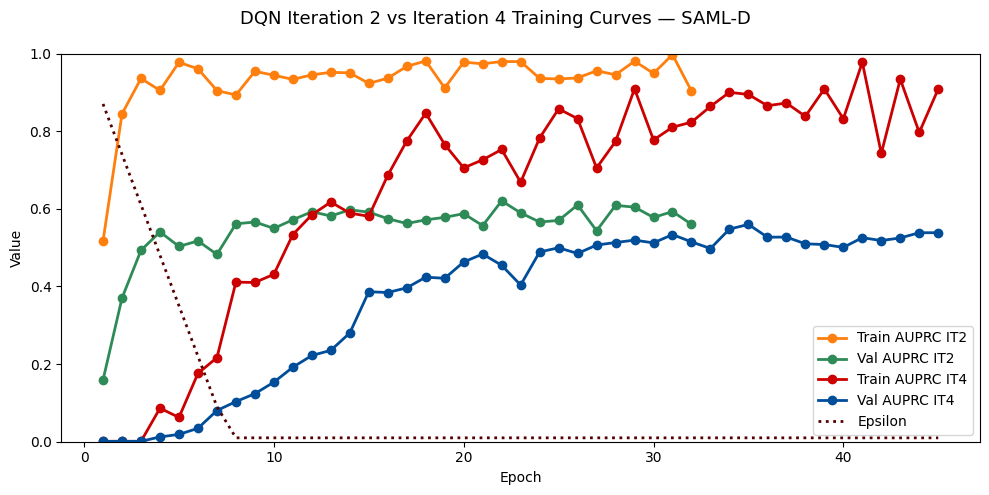

In [35]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('DQN Iteration 2 vs Iteration 4 Training Curves — SAML-D', fontsize=13)

epochs_v4 = history_v4['epoch']

ax.plot(epochs_v2, history_v2['train_auprc'], color='#ff7f0e', lw=2, linestyle='-', marker='o', label='Train AUPRC IT2')
ax.plot(epochs_v2, history_v2['val_auprc'], color='seagreen', lw=2, marker='o', label='Val AUPRC IT2')
ax.plot(epochs_v4, history_v4['train_auprc'], color='#cc0000', lw=2, marker='o', label='Train AUPRC IT4')
ax.plot(epochs_v4, history_v4['val_auprc'], color='#004d99', lw=2, marker='o', label='Val AUPRC IT4')
ax.plot(epochs_v4, history_v4['epsilon'], color='#550000', lw=2, linestyle=':', label='Epsilon')
ax.set_xlabel('Epoch')
ax.set_ylabel('Value')
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.savefig('dqn_v2_vs_v4_training_curves.png', dpi=150)
plt.show()

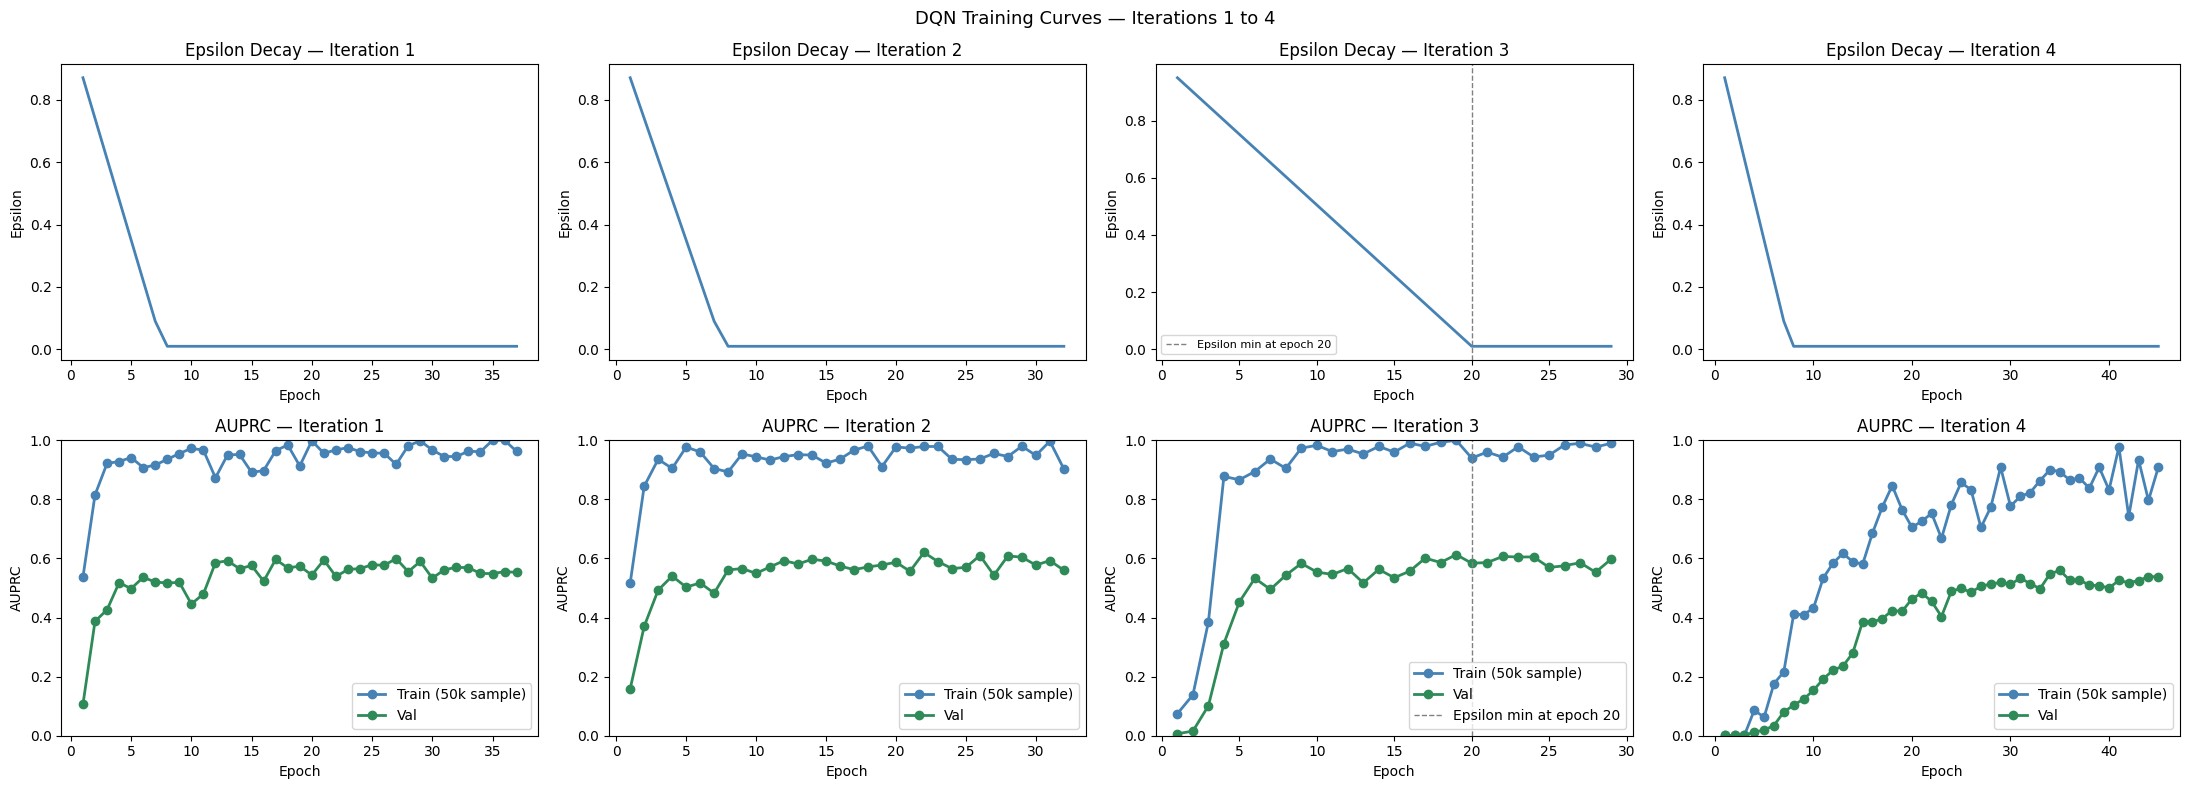

Saved: dqn_curves_it1_to_it4.png


In [36]:
fig, axes = plt.subplots(2, 4, figsize=(22, 8))
fig.suptitle('DQN Training Curves — Iterations 1 to 4', fontsize=13)

# Epsilon
axes[0, 0].plot(history_v1['epoch'], history_v1['epsilon'], color='steelblue', lw=2)
axes[0, 0].set_title('Epsilon Decay — Iteration 1')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Epsilon')

axes[0, 1].plot(history_v2['epoch'], history_v2['epsilon'], color='steelblue', lw=2)
axes[0, 1].set_title('Epsilon Decay — Iteration 2')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Epsilon')

axes[0, 2].plot(history_v3['epoch'], history_v3['epsilon'], color='steelblue', lw=2)
axes[0, 2].axvline(x=20, color='grey', lw=1, linestyle='--', label='Epsilon min at epoch 20')
axes[0, 2].set_title('Epsilon Decay — Iteration 3')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Epsilon')
axes[0, 2].legend(fontsize=8)

axes[0, 3].plot(history_v4['epoch'], history_v4['epsilon'], color='steelblue', lw=2)
axes[0, 3].set_title('Epsilon Decay — Iteration 4')
axes[0, 3].set_xlabel('Epoch')
axes[0, 3].set_ylabel('Epsilon')

# AUPRC
axes[1, 0].plot(history_v1['epoch'], history_v1['train_auprc'], color='steelblue', lw=2, marker='o', label='Train (50k sample)')
axes[1, 0].plot(history_v1['epoch'], history_v1['val_auprc'], color='seagreen', lw=2, marker='o', label='Val')
axes[1, 0].set_title('AUPRC — Iteration 1')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUPRC')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()

axes[1, 1].plot(history_v2['epoch'], history_v2['train_auprc'], color='steelblue', lw=2, marker='o', label='Train (50k sample)')
axes[1, 1].plot(history_v2['epoch'], history_v2['val_auprc'], color='seagreen', lw=2, marker='o', label='Val')
axes[1, 1].set_title('AUPRC — Iteration 2')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('AUPRC')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()

axes[1, 2].plot(history_v3['epoch'], history_v3['train_auprc'], color='steelblue', lw=2, marker='o', label='Train (50k sample)')
axes[1, 2].plot(history_v3['epoch'], history_v3['val_auprc'], color='seagreen', lw=2, marker='o', label='Val')
axes[1, 2].axvline(x=20, color='grey', lw=1, linestyle='--', label='Epsilon min at epoch 20')
axes[1, 2].set_title('AUPRC — Iteration 3')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('AUPRC')
axes[1, 2].set_ylim(0, 1)
axes[1, 2].legend()

axes[1, 3].plot(history_v4['epoch'], history_v4['train_auprc'], color='steelblue', lw=2, marker='o', label='Train (50k sample)')
axes[1, 3].plot(history_v4['epoch'], history_v4['val_auprc'], color='seagreen', lw=2, marker='o', label='Val')
axes[1, 3].set_title('AUPRC — Iteration 4')
axes[1, 3].set_xlabel('Epoch')
axes[1, 3].set_ylabel('AUPRC')
axes[1, 3].set_ylim(0, 1)
axes[1, 3].legend()

plt.tight_layout()
plt.savefig('dqn_curves_it1_to_it4.png', dpi=150)
plt.show()
print('Saved: dqn_curves_it1_to_it4.png')

## 6.5 Evaluation
The model in iteration 4, just like every other iteration, sits around the range of 0.54 - 0.62, indicating that dropout is likely not the solution either. On the other hand, the gap between train and val did get more narrow.

In [37]:
# Load best weights for evaluation
agent_v4.q_network.load_state_dict(torch.load("models/dqn_v4_best.pt", map_location=DEVICE))

val_scores_v4, val_auprc_v4 = evaluate(agent_v4, X_val_sc, y_val, "DQN Iteration 4 - Validation")

print("" + "=" * 55)
print("COMPARISON - All Iterations Validation AUPRC")
print("=" * 55)
print(f"  DQN Iteration 1 (Lin)         : {val_auprc_v1:.4f}")
print(f"  DQN Iteration 2 (ZV)          : {val_auprc_v2:.4f}")
print(f"  DQN Iteration 3 (ZV + e decay): {val_auprc_v3:.4f}")
print(f"  DQN Iteration 4 (ZV + dropout): {val_auprc_v4:.4f}")
print("=" * 55)
print("Test set evaluation is performed in the Comparison section.")


DQN Iteration 4 - Validation AUPRC: 0.5598
COMPARISON - All Iterations Validation AUPRC
  DQN Iteration 1 (Lin)         : 0.5994
  DQN Iteration 2 (ZV)          : 0.6203
  DQN Iteration 3 (ZV + e decay): 0.6132
  DQN Iteration 4 (ZV + dropout): 0.5598
Test set evaluation is performed in the Comparison section.


---

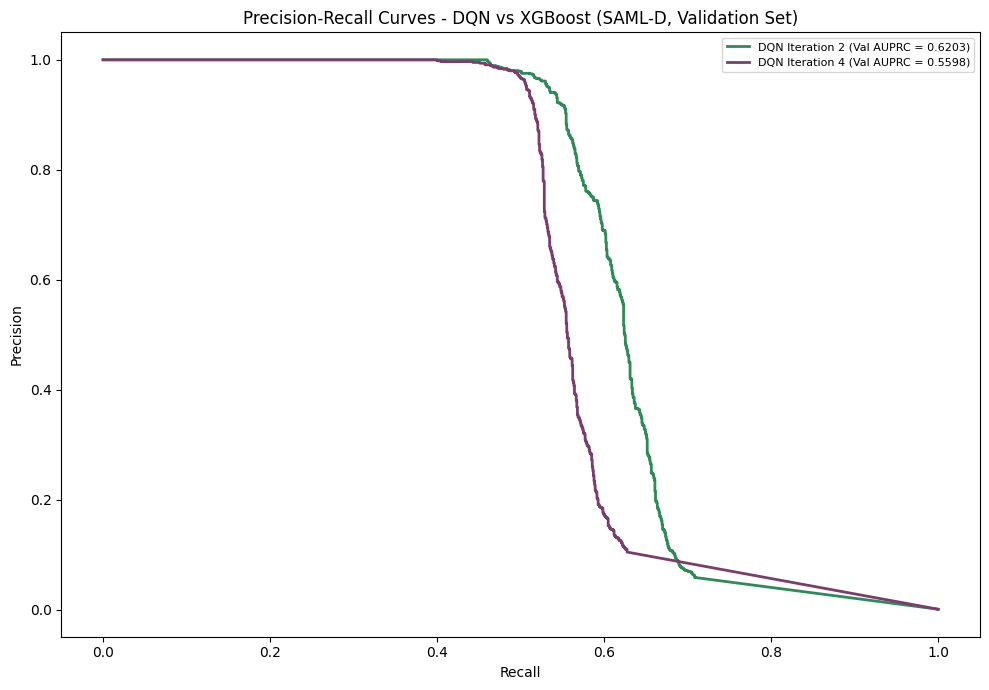

In [39]:
prec_v4, rec_v4, _ = precision_recall_curve(y_val, val_scores_v4)

plt.figure(figsize=(10, 7))
plt.plot(rec_v2, prec_v2, color='seagreen', lw=2, linestyle='-', label=f'DQN Iteration 2 (Val AUPRC = {val_auprc_v2:.4f})')
plt.plot(rec_v4, prec_v4, color='#7a3d6e', lw=2, linestyle='-', label=f'DQN Iteration 4 (Val AUPRC = {val_auprc_v4:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - DQN vs XGBoost (SAML-D, Validation Set)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('pr_curve_after_it4.png', dpi=150)
plt.show()

---

# 7. Iteration 5: Zhinin-Vera et al. (2020) — Reduced Dropout Rate

Iteration 4 added dropout with p = 0.5 to all hidden layers following [Srivastava et al. (2014)](#references). While the train/val AUPRC gap narrowed relative to earlier iterations — train AUPRC dropped from 0.95-1.0 to 0.7-0.9, the overall performance also declined, with best val AUPRC falling from 0.6203 (Iteration 2) to 0.5598 (Iteration 4). Crucially, train AUPRC also dropped significantly, indicating the network is no longer overfitting as severely but has also lost the capacity to learn strong patterns from the training data. This suggests that p = 0.5 might be too aggressive for this network and dataset combination.

[Srivastava et al. (2014)](#references) note that the optimal dropout rate depends on the network size and task. Their recommendation of p = 0.5 is derived from experiments on large networks with thousands of hidden units. The Q-network used here is considerably smaller (124-62-31-15), and the reward signal is already sparse due to the 0.104% class imbalance in SAML-D. Applying heavy dropout to a small network with a weak learning signal compounds the difficulty of training.

Iteration 5 reduces the dropout rate to p = 0.2 as a more conservative regularisation. All other hyperparameters remain identical to Iteration 4 to isolate the dropout rate as the only variable.

## 7.1 Training Configuration

In [40]:
# Iteration 5 -- Zhinin-Vera et al. (2020) + reduced dropout rate
# All parameters identical to Iteration 4 except DROPOUT_RATE
N_EPOCHS           = 100
MEMORY_SIZE        = 6653396
BATCH_SIZE         = 256
GAMMA              = 0.9      # Zhinin-Vera et al. (2020)
LAMBDA             = 0.1      # Zhinin-Vera et al. (2020)
EPSILON_START      = 1.0      # Lin et al. (2019)
EPSILON_DECAY      = 0.00001  # scaled for SAML-D
EPSILON_MIN        = 0.01     # Lin et al. (2019)
LR                 = 0.00025  # Lin et al. (2019)
TRAIN_FREQ         = 10       # Qayoom et al. (2024)
TARGET_UPDATE_FREQ = 20       # Qayoom et al. (2024)
DROPOUT_RATE       = 0.2      # reduced from 0.5 -- Srivastava et al. (2014)

EARLY_STOPPING_PATIENCE  = 10
EARLY_STOPPING_MIN_DELTA = 0.001

print('Iteration 5 -- Zhinin-Vera et al. (2020) + reduced dropout:')
print(f'  Lambda (lambda)     : {LAMBDA}')
print(f'  Gamma               : {GAMMA}')
print(f'  Dropout rate        : {DROPOUT_RATE}')
print(f'  Epochs (max)        : {N_EPOCHS}')
print(f'  Memory size         : {MEMORY_SIZE:,}')
print(f'  Batch size          : {BATCH_SIZE}')
print(f'  Epsilon start/decay/min: {EPSILON_START} / {EPSILON_DECAY} / {EPSILON_MIN}')
print(f'  Learning rate       : {LR}')
print(f'  Train freq          : {TRAIN_FREQ}')
print(f'  Target update freq  : {TARGET_UPDATE_FREQ}')
print(f'  Device              : {DEVICE}')


Iteration 5 -- Zhinin-Vera et al. (2020) + reduced dropout:
  Lambda (lambda)     : 0.1
  Gamma               : 0.9
  Dropout rate        : 0.2
  Epochs (max)        : 100
  Memory size         : 6,653,396
  Batch size          : 256
  Epsilon start/decay/min: 1.0 / 1e-05 / 0.01
  Learning rate       : 0.00025
  Train freq          : 10
  Target update freq  : 20
  Device              : cuda


## 7.2 Training Loop

In [41]:
# # Initialise agent -- Iteration 5
# agent_v5 = DQNAgentDropout(
#     n_features         = N_FEATURES,
#     dropout_rate       = DROPOUT_RATE,
#     memory_size        = MEMORY_SIZE,
#     batch_size         = BATCH_SIZE,
#     gamma              = GAMMA,
#     epsilon            = EPSILON_START,
#     epsilon_decay      = EPSILON_DECAY,
#     epsilon_min        = EPSILON_MIN,
#     lr                 = LR,
#     train_freq         = TRAIN_FREQ,
#     target_update_freq = TARGET_UPDATE_FREQ,
# )

# history_v5 = {
#     'epoch'       : [],
#     'reward'      : [],
#     'loss'        : [],
#     'epsilon'     : [],
#     'train_auprc' : [],
#     'val_auprc'   : [],
#     'elapsed'     : [],
# }

# best_val_auprc_v5 = 0.0
# no_improve_count  = 0
# total_start       = time.time()

# for epoch in range(1, N_EPOCHS + 1):
#     epoch_start = time.time()

#     perm       = np.random.permutation(len(X_train_sc))
#     X_shuffled = X_train_sc[perm]
#     y_shuffled = y_train[perm]

#     total_reward = 0.0
#     losses       = []
#     step_count   = 0
#     CHUNK        = 512
#     n_chunks     = (len(X_shuffled) + CHUNK - 1) // CHUNK

#     for ci, i in enumerate(range(0, len(X_shuffled), CHUNK)):
#         states = X_shuffled[i:i+CHUNK]
#         labels = y_shuffled[i:i+CHUNK]

#         if random.random() < agent_v5.epsilon:
#             actions = np.random.randint(0, 2, size=len(states))
#         else:
#             with torch.no_grad():
#                 q = agent_v5.q_network(torch.FloatTensor(states).to(DEVICE))
#             actions = q.argmax(dim=1).cpu().numpy()

#         rewards = np.where(
#             actions == 1,
#             np.where(labels == 1, +1.0, -LAMBDA),
#             np.where(labels == 1, -1.0, +LAMBDA),
#         ).astype(np.float32)

#         total_reward += rewards.sum()

#         for j in range(len(states)):
#             done_flag  = (i + j + 1) >= len(X_shuffled)
#             next_state = X_shuffled[i+j+1] if not done_flag else np.zeros(N_FEATURES, dtype=np.float32)
#             agent_v5.memory.push(states[j], int(actions[j]), float(rewards[j]), next_state, done_flag)

#         agent_v5.decay_epsilon()
#         step_count += len(states)

#         if step_count % TRAIN_FREQ == 0:
#             loss = agent_v5.train_step()
#             if loss is not None:
#                 losses.append(loss)

#         if step_count % TARGET_UPDATE_FREQ == 0:
#             agent_v5.update_target()

#         if (ci + 1) % 1000 == 0:
#             elapsed = time.time() - epoch_start
#             pct     = (ci + 1) / n_chunks * 100
#             print(f'  Epoch {epoch} | {pct:.1f}% | {elapsed:.0f}s elapsed', end='\r')

#     train_sample_idx = np.random.choice(len(X_train_sc), size=50000, replace=False)
#     train_scores     = agent_v5.get_scores(X_train_sc[train_sample_idx])
#     train_auprc      = average_precision_score(y_train[train_sample_idx], train_scores)

#     val_scores = agent_v5.get_scores(X_val_sc)
#     val_auprc  = average_precision_score(y_val, val_scores)

#     epoch_loss    = np.mean(losses) if losses else float('nan')
#     epoch_elapsed = time.time() - epoch_start

#     history_v5['epoch'].append(epoch)
#     history_v5['reward'].append(total_reward)
#     history_v5['loss'].append(epoch_loss)
#     history_v5['epsilon'].append(agent_v5.epsilon)
#     history_v5['train_auprc'].append(train_auprc)
#     history_v5['val_auprc'].append(val_auprc)
#     history_v5['elapsed'].append(epoch_elapsed)

#     if val_auprc > best_val_auprc_v5 + EARLY_STOPPING_MIN_DELTA:
#         best_val_auprc_v5 = val_auprc
#         no_improve_count  = 0
#         torch.save(agent_v5.q_network.state_dict(), 'dqn_v5_best.pt')
#         best_marker = ' <- best'
#     else:
#         no_improve_count += 1
#         best_marker = f' (no improve {no_improve_count}/{EARLY_STOPPING_PATIENCE})'

#     if epoch % 5 == 0:
#         torch.save(agent_v5.q_network.state_dict(), f'dqn_v5_epoch{epoch}.pt')
#         print(f'  Checkpoint saved: dqn_v5_epoch{epoch}.pt')

#     print(
#         f'Epoch {epoch:>2}/{N_EPOCHS} | '
#         f'Reward: {total_reward:>10.1f} | '
#         f'Loss: {epoch_loss:.4f} | '
#         f'Epsilon: {agent_v5.epsilon:.4f} | '
#         f'Train AUPRC: {train_auprc:.4f} | '
#         f'Val AUPRC: {val_auprc:.4f} | '
#         f'Time: {epoch_elapsed:.0f}s'
#         f'{best_marker}'
#     )

#     if no_improve_count >= EARLY_STOPPING_PATIENCE:
#         print(f'\nEarly stopping triggered - no improvement of >{EARLY_STOPPING_MIN_DELTA} '
#               f'for {EARLY_STOPPING_PATIENCE} consecutive epochs.')
#         break

# total_elapsed = time.time() - total_start
# print(f'\nIteration 5 complete in {total_elapsed/60:.1f} minutes')
# print(f'Best validation AUPRC: {best_val_auprc_v5:.4f} | Stopped at epoch: {epoch}')
# torch.save(agent_v5.q_network.state_dict(), 'dqn_v5_final.pt')
# print('Saved: dqn_v5_best.pt | dqn_v5_final.pt | dqn_v5_epoch5/10/...pt')


# # Save history to disk
# import json
# with open('history_v5.json', 'w') as f:
#     json.dump(history_v5, f)
# print('Saved: history_v5.json')

In [42]:
# ── LOAD MODEL AND HISTORY (run this instead of training loop if model already trained) ──
# Uncomment the block below to load saved model and history

import json
agent_v5 = DQNAgentDropout(
    n_features         = N_FEATURES,
    dropout_rate       = 0.2,
    memory_size        = MEMORY_SIZE,
    batch_size         = BATCH_SIZE,
    gamma              = GAMMA,
    epsilon            = EPSILON_MIN,
    epsilon_decay      = EPSILON_DECAY,
    epsilon_min        = EPSILON_MIN,
    lr                 = LR,
    train_freq         = TRAIN_FREQ,
    target_update_freq = TARGET_UPDATE_FREQ,
)
agent_v5.q_network.load_state_dict(torch.load('models/dqn_v5_best.pt', map_location=DEVICE))
agent_v5.q_network.eval()
with open('models/history_v5.json') as f:
    history_v5 = json.load(f)
print('Loaded: dqn_v5_best.pt and history_v5.json')

Loaded: dqn_v5_best.pt and history_v5.json


## 7.3 Training Curves

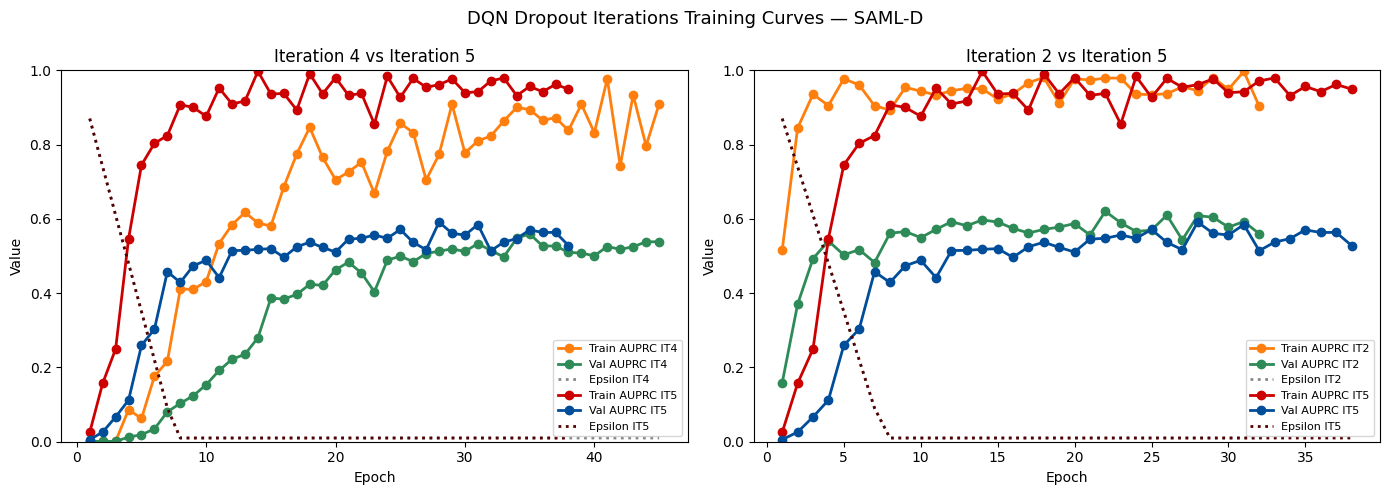

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DQN Dropout Iterations Training Curves — SAML-D', fontsize=13)

epochs_v4 = history_v4['epoch']
epochs_v5 = history_v5['epoch']

# Left: IT4 vs IT5
axes[0].set_title('Iteration 4 vs Iteration 5')
axes[0].plot(epochs_v4, history_v4['train_auprc'], color='#ff7f0e', lw=2, marker='o', label='Train AUPRC IT4')
axes[0].plot(epochs_v4, history_v4['val_auprc'], color='seagreen', lw=2, marker='o', label='Val AUPRC IT4')
axes[0].plot(epochs_v4, history_v4['epsilon'], color='#888888', lw=2, linestyle=':', label='Epsilon IT4')
axes[0].plot(epochs_v5, history_v5['train_auprc'], color='#cc0000', lw=2, marker='o', label='Train AUPRC IT5')
axes[0].plot(epochs_v5, history_v5['val_auprc'], color='#004d99', lw=2, marker='o', label='Val AUPRC IT5')
axes[0].plot(epochs_v5, history_v5['epsilon'], color='#550000', lw=2, linestyle=':', label='Epsilon IT5')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Value')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)

# Right: IT5 vs IT2
axes[1].set_title('Iteration 2 vs Iteration 5')
axes[1].plot(epochs_v2, history_v2['train_auprc'], color='#ff7f0e', lw=2, marker='o', label='Train AUPRC IT2')
axes[1].plot(epochs_v2, history_v2['val_auprc'], color='seagreen', lw=2, marker='o', label='Val AUPRC IT2')
axes[1].plot(epochs_v2, history_v2['epsilon'], color='#888888', lw=2, linestyle=':', label='Epsilon IT2')
axes[1].plot(epochs_v5, history_v5['train_auprc'], color='#cc0000', lw=2, marker='o', label='Train AUPRC IT5')
axes[1].plot(epochs_v5, history_v5['val_auprc'], color='#004d99', lw=2, marker='o', label='Val AUPRC IT5')
axes[1].plot(epochs_v5, history_v5['epsilon'], color='#550000', lw=2, linestyle=':', label='Epsilon IT5')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Value')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('dqn_v2_vs_v4_vs_v5_training_curves.png', dpi=150)
plt.show()

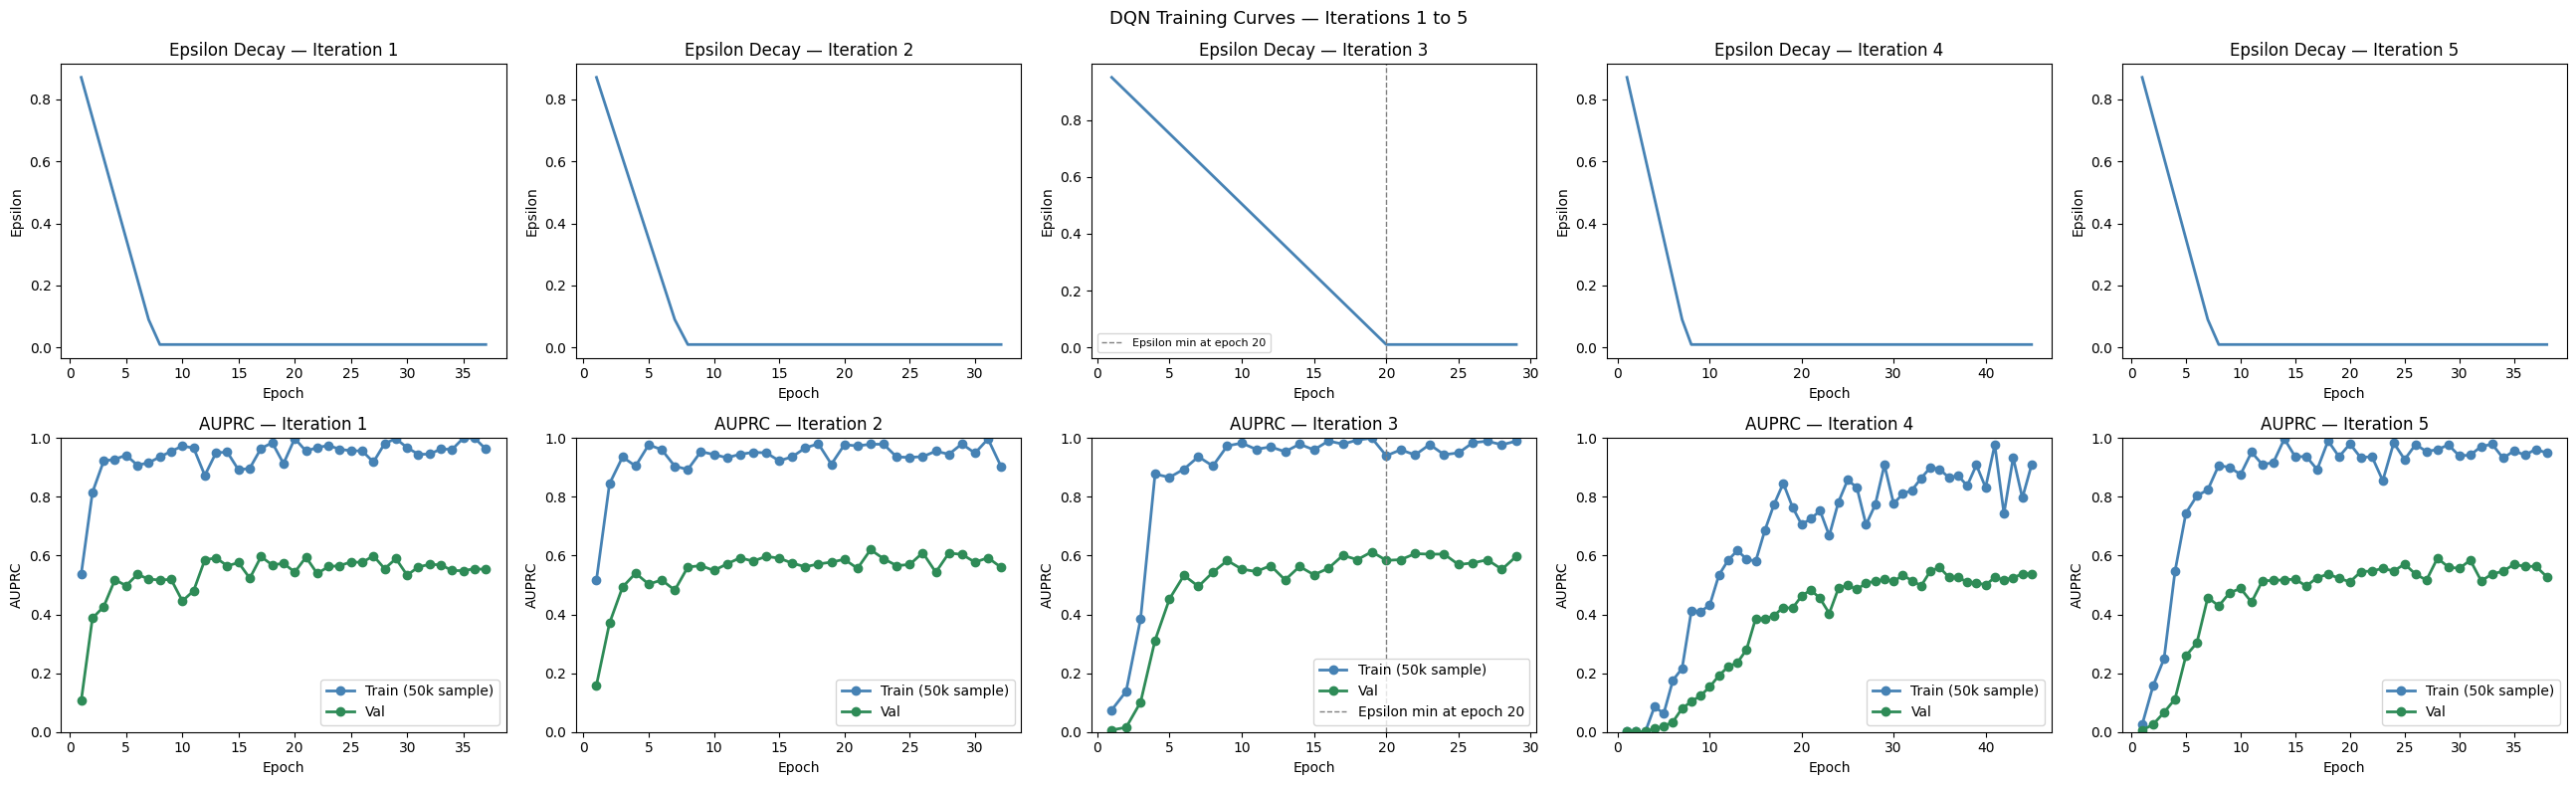

Saved: dqn_curves_it1_to_it5.png


In [44]:
fig, axes = plt.subplots(2, 5, figsize=(26, 8))
fig.suptitle('DQN Training Curves — Iterations 1 to 5', fontsize=13)

# Epsilon
axes[0, 0].plot(history_v1['epoch'], history_v1['epsilon'], color='steelblue', lw=2)
axes[0, 0].set_title('Epsilon Decay — Iteration 1')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Epsilon')

axes[0, 1].plot(history_v2['epoch'], history_v2['epsilon'], color='steelblue', lw=2)
axes[0, 1].set_title('Epsilon Decay — Iteration 2')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Epsilon')

axes[0, 2].plot(history_v3['epoch'], history_v3['epsilon'], color='steelblue', lw=2)
axes[0, 2].axvline(x=20, color='grey', lw=1, linestyle='--', label='Epsilon min at epoch 20')
axes[0, 2].set_title('Epsilon Decay — Iteration 3')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Epsilon')
axes[0, 2].legend(fontsize=8)

axes[0, 3].plot(history_v4['epoch'], history_v4['epsilon'], color='steelblue', lw=2)
axes[0, 3].set_title('Epsilon Decay — Iteration 4')
axes[0, 3].set_xlabel('Epoch')
axes[0, 3].set_ylabel('Epsilon')

axes[0, 4].plot(history_v5['epoch'], history_v5['epsilon'], color='steelblue', lw=2)
axes[0, 4].set_title('Epsilon Decay — Iteration 5')
axes[0, 4].set_xlabel('Epoch')
axes[0, 4].set_ylabel('Epsilon')

# AUPRC
axes[1, 0].plot(history_v1['epoch'], history_v1['train_auprc'], color='steelblue', lw=2, marker='o', label='Train (50k sample)')
axes[1, 0].plot(history_v1['epoch'], history_v1['val_auprc'], color='seagreen', lw=2, marker='o', label='Val')
axes[1, 0].set_title('AUPRC — Iteration 1')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUPRC')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend()

axes[1, 1].plot(history_v2['epoch'], history_v2['train_auprc'], color='steelblue', lw=2, marker='o', label='Train (50k sample)')
axes[1, 1].plot(history_v2['epoch'], history_v2['val_auprc'], color='seagreen', lw=2, marker='o', label='Val')
axes[1, 1].set_title('AUPRC — Iteration 2')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('AUPRC')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()

axes[1, 2].plot(history_v3['epoch'], history_v3['train_auprc'], color='steelblue', lw=2, marker='o', label='Train (50k sample)')
axes[1, 2].plot(history_v3['epoch'], history_v3['val_auprc'], color='seagreen', lw=2, marker='o', label='Val')
axes[1, 2].axvline(x=20, color='grey', lw=1, linestyle='--', label='Epsilon min at epoch 20')
axes[1, 2].set_title('AUPRC — Iteration 3')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('AUPRC')
axes[1, 2].set_ylim(0, 1)
axes[1, 2].legend()

axes[1, 3].plot(history_v4['epoch'], history_v4['train_auprc'], color='steelblue', lw=2, marker='o', label='Train (50k sample)')
axes[1, 3].plot(history_v4['epoch'], history_v4['val_auprc'], color='seagreen', lw=2, marker='o', label='Val')
axes[1, 3].set_title('AUPRC — Iteration 4')
axes[1, 3].set_xlabel('Epoch')
axes[1, 3].set_ylabel('AUPRC')
axes[1, 3].set_ylim(0, 1)
axes[1, 3].legend()

axes[1, 4].plot(history_v5['epoch'], history_v5['train_auprc'], color='steelblue', lw=2, marker='o', label='Train (50k sample)')
axes[1, 4].plot(history_v5['epoch'], history_v5['val_auprc'], color='seagreen', lw=2, marker='o', label='Val')
axes[1, 4].set_title('AUPRC — Iteration 5')
axes[1, 4].set_xlabel('Epoch')
axes[1, 4].set_ylabel('AUPRC')
axes[1, 4].set_ylim(0, 1)
axes[1, 4].legend()

plt.tight_layout()
plt.savefig('dqn_curves_it1_to_it5.png', dpi=150)
plt.show()
print('Saved: dqn_curves_it1_to_it5.png')

## 7.4 Evaluation
Overall performance rises up, but the model still seems to overfit on the train data, as the validation score stays low.

In [45]:
# Load best weights for evaluation
agent_v5.q_network.load_state_dict(torch.load('models/dqn_v5_best.pt', map_location=DEVICE))

val_scores_v5, val_auprc_v5 = evaluate(agent_v5, X_val_sc, y_val, 'DQN Iteration 5 - Validation')

print('\n' + '=' * 60)
print('COMPARISON - All Iterations Validation AUPRC')
print('=' * 60)
print(f'  DQN Iteration 1 (Lin)            : {val_auprc_v1:.4f}')
print(f'  DQN Iteration 2 (ZV)             : {val_auprc_v2:.4f}')
print(f'  DQN Iteration 3 (ZV + e decay)   : {val_auprc_v3:.4f}')
print(f'  DQN Iteration 4 (ZV + drop 0.5)  : {val_auprc_v4:.4f}')
print(f'  DQN Iteration 5 (ZV + drop 0.2)  : {val_auprc_v5:.4f}')
print('=' * 60)
print('Test set evaluation is performed in the Comparison section.')



DQN Iteration 5 - Validation AUPRC: 0.5914

COMPARISON - All Iterations Validation AUPRC
  DQN Iteration 1 (Lin)            : 0.5994
  DQN Iteration 2 (ZV)             : 0.6203
  DQN Iteration 3 (ZV + e decay)   : 0.6132
  DQN Iteration 4 (ZV + drop 0.5)  : 0.5598
  DQN Iteration 5 (ZV + drop 0.2)  : 0.5914
Test set evaluation is performed in the Comparison section.


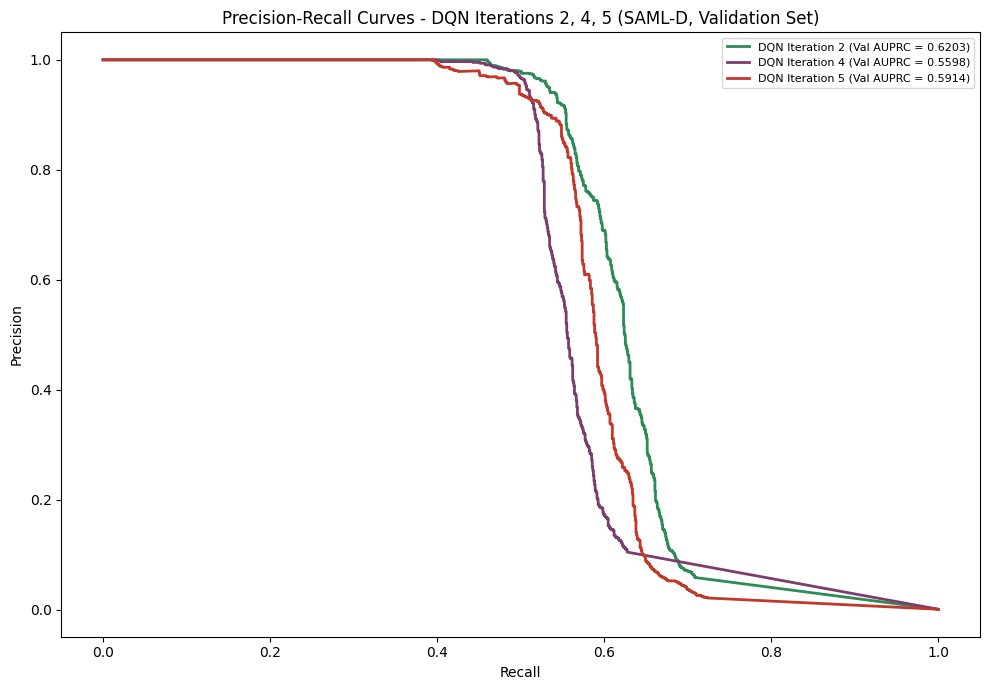

In [ ]:
prec_v5, rec_v5, _ = precision_recall_curve(y_val, val_scores_v5)

plt.figure(figsize=(10, 7))
plt.plot(rec_v2, prec_v2, color='seagreen', lw=2,
         label=f'DQN Iteration 2 (Val AUPRC = {val_auprc_v2:.4f})')
plt.plot(rec_v4, prec_v4, color='#7a3d6e', lw=2,
         label=f'DQN Iteration 4 (Val AUPRC = {val_auprc_v4:.4f})')
plt.plot(rec_v5, prec_v5, color='#c0392b', lw=2,
         label=f'DQN Iteration 5 (Val AUPRC = {val_auprc_v5:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - DQN Iterations 2, 4, 5 (SAML-D, Validation Set)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('pr_curve_after_it5.png', dpi=150)
plt.show()

---


# 9. Comparison

The table below summarises the validation and test AUPRC across all six DQN iterations alongside the XGBoost benchmark.

| Model | Val AUPRC | Test AUPRC |
|---|---|---|
| XGBoost Iteration 3 (Optuna) | 0.9136 | 0.9275 |
| DQN Iteration 1 (Lin et al., λ = ρ) | 0.5994 | 0.6450 |
| DQN Iteration 2 (Zhinin-Vera, λ = 0.1) | 0.6203 | 0.6608 |
| DQN Iteration 3 (Zhinin-Vera, adjusted ε decay) | 0.6132 | 0.6691 |
| DQN Iteration 4 (Zhinin-Vera, dropout p = 0.5) | 0.5598 | 0.5578 |
| DQN Iteration 5 (Zhinin-Vera, dropout p = 0.2) | 0.5914 | 0.6197 |

Iteration 3 achieves the highest test AUPRC among all DQN iterations at 0.6691, marginally above Iteration 2 (0.6608). However, the difference of 0.0083 is negligible and no strong conclusions can be drawn about the effect of the adjusted epsilon decay. Iteration 2 is therefore selected as the final DQN model for comparison against XGBoost, as it achieves comparable performance with a simpler configuration that follows the Zhinin-Vera et al.~\cite{zhininvera2020} reward function more directly.

Iterations 4 and 5 tested dropout regularisation at $p = 0.5$ and $p = 0.2$ respectively. Neither improved over Iteration 2. Dropout at $p = 0.5$ reduced the gap between train and validation AUPRC but also reduced overall performance, suggesting the network lost too much learning capacity. Reducing the dropout rate to $p = 0.2$ partially recovered performance but still did not reach Iteration 2 levels, indicating that dropout regularisation does not benefit this architecture and dataset.


DQN Iteration 1 - Test AUPRC: 0.6450

DQN Iteration 2 - Test AUPRC: 0.6608

DQN Iteration 3 - Test AUPRC: 0.6691

DQN Iteration 4 - Test AUPRC: 0.5578

DQN Iteration 5 - Test AUPRC: 0.6197
  Model                               Test AUPRC
  DQN Iteration 1 (Lin, λ=ρ)              0.6450
  DQN Iteration 2 (ZV, λ=0.1)             0.6608
  DQN Iteration 3 (ZV + ε decay)          0.6691
  DQN Iteration 4 (ZV + drop 0.5)         0.5578
  DQN Iteration 5 (ZV + drop 0.2)         0.6197


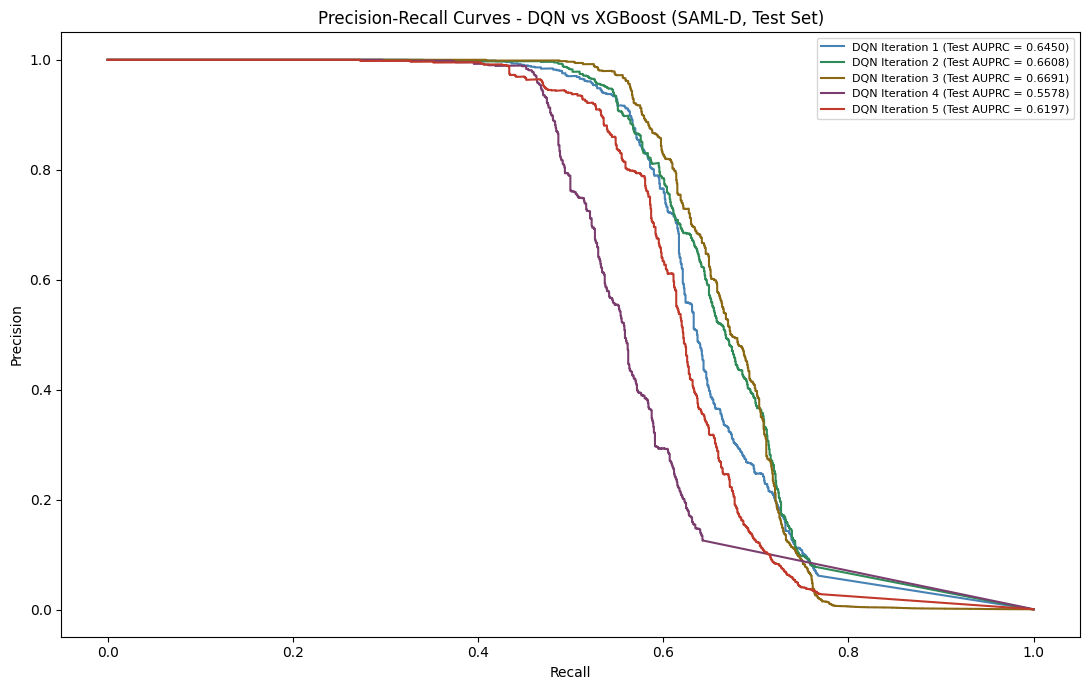

In [49]:
import xgboost as xgb

# Load all DQN best models
agent_v1.q_network.load_state_dict(torch.load('models/dqn_v1_best.pt', map_location=DEVICE))
agent_v2.q_network.load_state_dict(torch.load('models/dqn_v2_best.pt', map_location=DEVICE))
agent_v3.q_network.load_state_dict(torch.load('models/dqn_v3_best.pt', map_location=DEVICE))
agent_v4.q_network.load_state_dict(torch.load('models/dqn_v4_best.pt', map_location=DEVICE))
agent_v5.q_network.load_state_dict(torch.load('models/dqn_v5_best.pt', map_location=DEVICE))

test_scores_v1, test_auprc_v1 = evaluate(agent_v1, X_test_sc, y_test, 'DQN Iteration 1 - Test')
test_scores_v2, test_auprc_v2 = evaluate(agent_v2, X_test_sc, y_test, 'DQN Iteration 2 - Test')
test_scores_v3, test_auprc_v3 = evaluate(agent_v3, X_test_sc, y_test, 'DQN Iteration 3 - Test')
test_scores_v4, test_auprc_v4 = evaluate(agent_v4, X_test_sc, y_test, 'DQN Iteration 4 - Test')
test_scores_v5, test_auprc_v5 = evaluate(agent_v5, X_test_sc, y_test, 'DQN Iteration 5 - Test')

# Load all three XGBoost models
def load_xgb_test_scores(model_path):
    model = xgb.XGBClassifier()
    model.load_model(model_path)
    X = test_df.drop(columns=DROP_COLS).copy()
    for col in X.select_dtypes('object').columns:
        X[col] = X[col].astype('category')
    scores = model.predict_proba(X)[:, 1]
    auprc  = average_precision_score(y_test, scores)
    return scores, auprc

xgb3_test_scores, xgb3_test_auprc = load_xgb_test_scores('../XGBoost/xgboost_aml_optuna.json')

# Results table
print('=' * 60)
print(f'  {"Model":<35} {"Test AUPRC":>10}')
print('=' * 60)
print(f'  {"DQN Iteration 1 (Lin, λ=ρ)":<35} {test_auprc_v1:>10.4f}')
print(f'  {"DQN Iteration 2 (ZV, λ=0.1)":<35} {test_auprc_v2:>10.4f}')
print(f'  {"DQN Iteration 3 (ZV + ε decay)":<35} {test_auprc_v3:>10.4f}')
print(f'  {"DQN Iteration 4 (ZV + drop 0.5)":<35} {test_auprc_v4:>10.4f}')
print(f'  {"DQN Iteration 5 (ZV + drop 0.2)":<35} {test_auprc_v5:>10.4f}')
print('=' * 60)

# PR curves — all iterations
prec_v1, rec_v1, _ = precision_recall_curve(y_test, test_scores_v1)
prec_v2, rec_v2, _ = precision_recall_curve(y_test, test_scores_v2)
prec_v3, rec_v3, _ = precision_recall_curve(y_test, test_scores_v3)
prec_v4, rec_v4, _ = precision_recall_curve(y_test, test_scores_v4)
prec_v5, rec_v5, _ = precision_recall_curve(y_test, test_scores_v5)

plt.figure(figsize=(11, 7))
plt.plot(rec_v1, prec_v1, color='steelblue', lw=1.5,
         label=f'DQN Iteration 1 (Test AUPRC = {test_auprc_v1:.4f})')
plt.plot(rec_v2, prec_v2, color='seagreen', lw=1.5,
         label=f'DQN Iteration 2 (Test AUPRC = {test_auprc_v2:.4f})')
plt.plot(rec_v3, prec_v3, color='#8b6914', lw=1.5,
         label=f'DQN Iteration 3 (Test AUPRC = {test_auprc_v3:.4f})')
plt.plot(rec_v4, prec_v4, color='#7a3d6e', lw=1.5,
         label=f'DQN Iteration 4 (Test AUPRC = {test_auprc_v4:.4f})')
plt.plot(rec_v5, prec_v5, color='#c0392b', lw=1.5,
         label=f'DQN Iteration 5 (Test AUPRC = {test_auprc_v5:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - DQN vs XGBoost (SAML-D, Test Set)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('pr_curve_final.png', dpi=150)
plt.show()

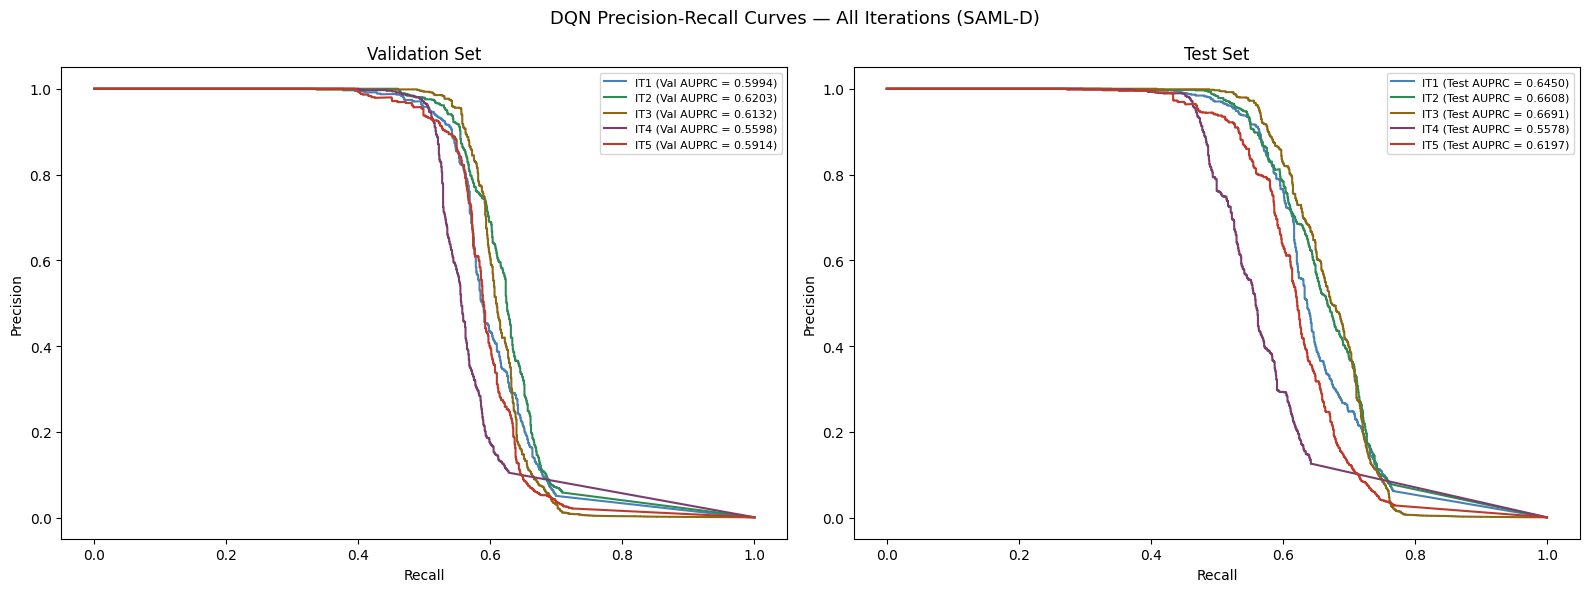

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('DQN Precision-Recall Curves — All Iterations (SAML-D)', fontsize=13)

# Validation set
axes[0].set_title('Validation Set')
axes[0].plot(rec_v1_val, prec_v1_val, color='steelblue', lw=1.5, label=f'IT1 (Val AUPRC = {val_auprc_v1:.4f})')
axes[0].plot(rec_v2_val, prec_v2_val, color='seagreen', lw=1.5, label=f'IT2 (Val AUPRC = {val_auprc_v2:.4f})')
axes[0].plot(rec_v3_val, prec_v3_val, color='#8b6914', lw=1.5, label=f'IT3 (Val AUPRC = {val_auprc_v3:.4f})')
axes[0].plot(rec_v4_val, prec_v4_val, color='#7a3d6e', lw=1.5, label=f'IT4 (Val AUPRC = {val_auprc_v4:.4f})')
axes[0].plot(rec_v5_val, prec_v5_val, color='#c0392b', lw=1.5, label=f'IT5 (Val AUPRC = {val_auprc_v5:.4f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].legend(fontsize=8)

# Test set
axes[1].set_title('Test Set')
axes[1].plot(rec_v1, prec_v1, color='steelblue', lw=1.5, label=f'IT1 (Test AUPRC = {test_auprc_v1:.4f})')
axes[1].plot(rec_v2, prec_v2, color='seagreen', lw=1.5, label=f'IT2 (Test AUPRC = {test_auprc_v2:.4f})')
axes[1].plot(rec_v3, prec_v3, color='#8b6914', lw=1.5, label=f'IT3 (Test AUPRC = {test_auprc_v3:.4f})')
axes[1].plot(rec_v4, prec_v4, color='#7a3d6e', lw=1.5, label=f'IT4 (Test AUPRC = {test_auprc_v4:.4f})')
axes[1].plot(rec_v5, prec_v5, color='#c0392b', lw=1.5, label=f'IT5 (Test AUPRC = {test_auprc_v5:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('pr_curve_all_dqn_val_test.png', dpi=150)
plt.show()

## 9.1 Best Models


DQN Iteration 2 - Test AUPRC: 0.6608

FINAL RESULTS - Test Set AUPRC
  XGBoost Iteration 2 (benchmark) : 0.9275
  DQN Iteration 2 (best DQN)      : 0.6608
  Difference                       : -0.2667 (below XGBoost)


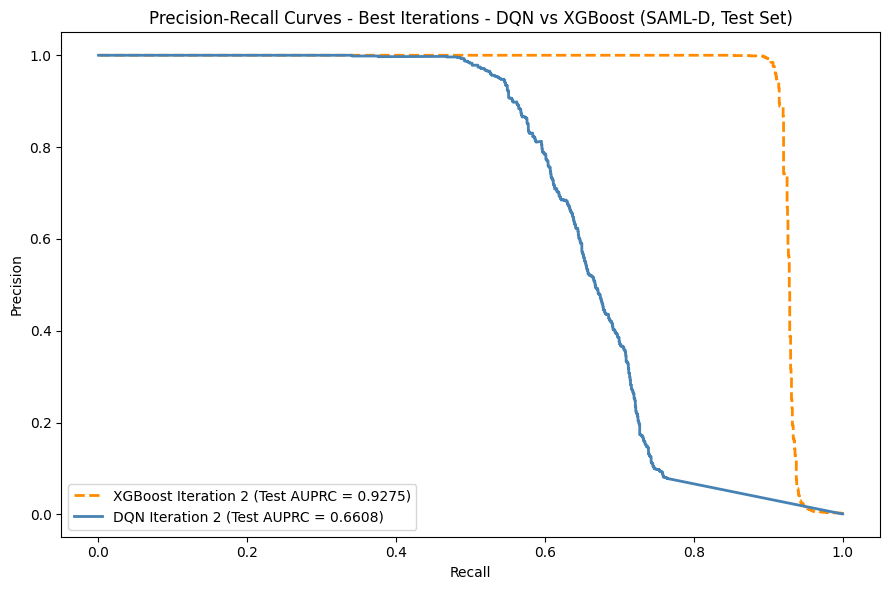

Saved: pr_curve_final_best_vs_best.png


In [52]:
import xgboost as xgb

# Load best DQN model — Iteration 2
agent_v2.q_network.load_state_dict(torch.load('models/dqn_v2_best.pt', map_location=DEVICE))
test_scores_v2, test_auprc_v2 = evaluate(agent_v2, X_test_sc, y_test, 'DQN Iteration 2 - Test')

# Load best XGBoost model — Iteration 2
xgb_model = xgb.XGBClassifier()
xgb_model.load_model('../XGBoost/xgboost_aml_optuna.json')
X_test_xgb = test_df.drop(columns=DROP_COLS).copy()
for col in X_test_xgb.select_dtypes('object').columns:
    X_test_xgb[col] = X_test_xgb[col].astype('category')
xgb_test_scores = xgb_model.predict_proba(X_test_xgb)[:, 1]
xgb_test_auprc  = average_precision_score(y_test, xgb_test_scores)

print('\n' + '=' * 55)
print('FINAL RESULTS - Test Set AUPRC')
print('=' * 55)
print(f'  XGBoost Iteration 2 (benchmark) : {xgb_test_auprc:.4f}')
print(f'  DQN Iteration 2 (best DQN)      : {test_auprc_v2:.4f}')
diff = test_auprc_v2 - xgb_test_auprc
print(f'  Difference                       : {diff:+.4f} ({"above" if diff > 0 else "below"} XGBoost)')
print('=' * 55)

# PR curves
prec_dqn, rec_dqn, _ = precision_recall_curve(y_test, test_scores_v2)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, xgb_test_scores)

plt.figure(figsize=(9, 6))
plt.plot(rec_xgb, prec_xgb, color='darkorange', lw=2, linestyle='--',
         label=f'XGBoost Iteration 2 (Test AUPRC = {xgb_test_auprc:.4f})')
plt.plot(rec_dqn, prec_dqn, color='steelblue', lw=2,
         label=f'DQN Iteration 2 (Test AUPRC = {test_auprc_v2:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - Best Iterations - DQN vs XGBoost (SAML-D, Test Set)')
plt.legend()
plt.tight_layout()
plt.savefig('pr_curve_final_best_vs_best.png', dpi=150)
plt.show()
print('Saved: pr_curve_final_best_vs_best.png')

---

# 11. Summary

This notebook implemented and evaluated a Deep Q-Network for Anti-Money Laundering detection on the SAML-D dataset [(Oztas et al., 2023)](#references) across two iterations. Both iterations use the same leakage-free chronological 70/15/15 split and 26-feature set as the XGBoost baseline in `XGBoost_v7_2.ipynb`. The table below summarises results across all models.

| Model | Val AUPRC | Test AUPRC
|---|---|---|
| XGBoost Iteration 3 (Optuna) | 0.9136 | 0.9275 |
| DQN Iteration 1 (Lin et al., λ = ρ) | 0.5994 | 0.6450 |
| DQN Iteration 2 (Zhinin-Vera, λ = 0.1) | 0.6203 | 0.6608 |
| DQN Iteration 3 (Zhinin-Vera, adjusted ε decay) | 0.6132 | 0.6691 |
| DQN Iteration 4 (Zhinin-Vera, dropout p = 0.5) | 0.5598 | 0.5578 |
| DQN Iteration 5 (Zhinin-Vera, dropout p = 0.2) | 0.5914 | 0.6197 |
| DQN Iteration 6 (Zhinin-Vera, balanced buffer) | 0.6144 | 0.6575 |

The XGBoost Iteration 2 model is used as the benchmark (Test AUPRC = 0.7739). A model is considered to outperform the baseline if it achieves a higher AUPRC score under the same experimental conditions (PvA, Section 3.4). If XGBoost outperforms the DQN, this constitutes a valid and informative finding, contributing to the literature as the first comparison of these two approaches on AML tabular data with legally required explainability (PvA, Section 8).

---

# 12. References
(Note: https://wetten.overheid.nl/ tends to be offline now and then)

###### Attard, M. and de Bruijn, L. (2026). Machine learning binnen ING. Guest lecture at Hogeschool van Amsterdam. Personal notes taken during presentation.

###### Han, J., Kamber, M., and Pei, J. (2011). Data Mining: Concepts and Techniques. 3rd edition. Morgan Kaufmann.

###### Lin, E., Chen, Q., and Qi, X. (2019). Deep reinforcement learning for imbalanced classification. Applied Intelligence, 50:2488–2502. https://doi.org/10.1007/s10489-020-01637-z.

###### Lundberg, S. M. and Lee, S.-I. (2017). A unified approach to interpreting model predictions. Advances in Neural Information Processing Systems, 30. https://proceedings.neurips.cc/paper/2017/hash/8a20a8621978632d76c43dfd28b67767-Abstract.html.

###### Menon, S. and Nguyen, T. (2026). AML at ABN AMRO. Guest lecture at Hogeschool van Amsterdam. Personal notes taken during presentation.

###### Ministerie van Financiën (2008). Wet ter voorkoming van witwassen en financieren van terrorisme (Wwft). https://wetten.overheid.nl/BWBR0024282/2026-01-01#Hoofdstuk3.

###### Mnih, V., Kavukcuoglu, K., Silver, D., Rusu, A. A., Veness, J., Bellemare, M. G., Graves, A., Riedmiller, M., Fidjeland, A. K., Ostrovski, G., Petersen, S., Beattie, C., Sadik, A., Antonoglou, I., King, H., Kumaran, D., Wierstra, D., Legg, S., and Hassabis, D. (2015). Human-level control through deep reinforcement learning. Nature, 518(7540):529–533. https://doi.org/10.1038/nature14236.

###### Oztas, B., Cetinkaya, D., Adedoyin, F., Budka, M., Dogan, H., and Aksu, G. (2023). Enhancing anti-money laundering: Development of a synthetic transaction monitoring dataset. In 2023 IEEE International Conference on e-Business Engineering (ICEBE), pages 47–54. https://doi.org/10.1109/ICEBE59045.2023.00028.

###### Qayoom, A., Khuhro, M. A., Kumar, K., Waqas, M., Saeed, U., ur Rehman, S., Wu, Y., and Wang, S. (2024). A novel approach for credit card fraud transaction detection using deep reinforcement learning scheme. PeerJ Computer Science, 10:e1998. https://doi.org/10.7717/peerj-cs.1998.

###### Vimal, S., Kayathwal, K., Wadhwa, H., and Dhama, G. (2021). Application of deep reinforcement learning to payment fraud. arXiv preprint arXiv:2112.04236. https://arxiv.org/abs/2112.04236.

###### Youssef, B., Bouchra, F., and Brahim, O. (2023). State of the art literature on anti-money laundering using machine learning and deep learning techniques. In The 3rd International Conference on Artificial Intelligence and Computer Vision (AICV2023), March 5–7, 2023, pages 77–90. Springer Nature Switzerland. https://rdcu.be/e8mZQ.

###### Zhinin-Vera, L., Chang, O., Valencia-Ramos, R., Velastegui, R., Pilliza, G. E., and Quinga-Socasi, F. (2020). Q-Credit card fraud detector for imbalanced classification using reinforcement learning. In Proceedings of the 12th International Conference on Agents and Artificial Intelligence (ICAART 2020), Volume 1, pages 279–286. https://doi.org/10.5220/0009156102790286.